In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import scipy
from sklearn.neighbors import LocalOutlierFactor

In [38]:
df = pd.read_pickle('../data/interim/01_data_resampled.pkl')

In [39]:
outlier_col =list (df.columns[:6])

In [40]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100

In [41]:
df

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set
epoch (ms),,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30
...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,90
2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,90
2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,90


<Axes: title={'center': 'gyro_y'}, xlabel='[label]'>

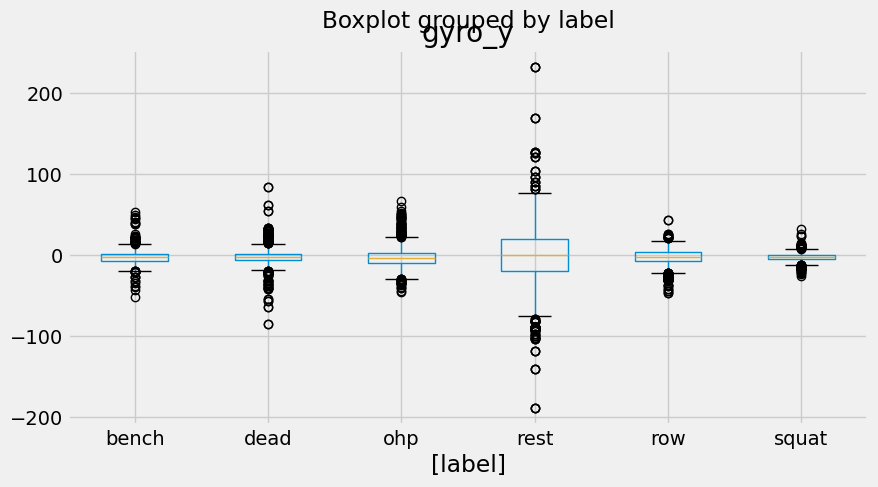

In [42]:
df[['gyro_y','label']].boxplot(by='label', figsize=(10, 5))

array([<Axes: title={'center': 'acc_x'}, xlabel='[label]'>,
       <Axes: title={'center': 'acc_y'}, xlabel='[label]'>,
       <Axes: title={'center': 'acc_z'}, xlabel='[label]'>], dtype=object)

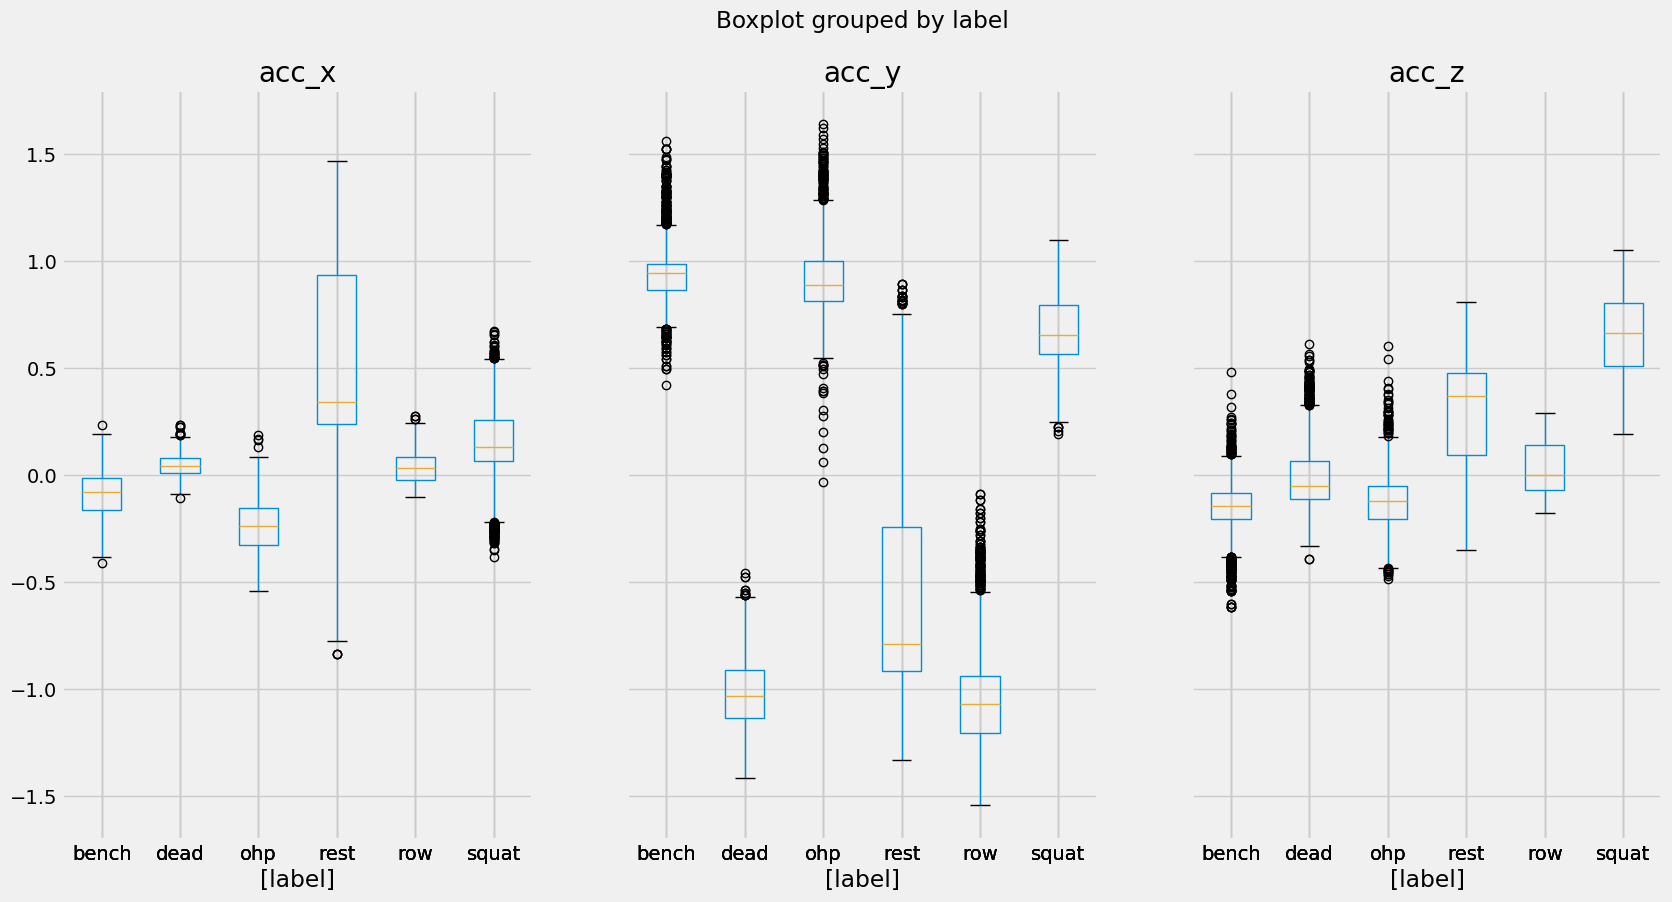

In [43]:
df[outlier_col[:3] +['label']].boxplot(by='label', figsize=(20,10),layout=(1,3))

array([<Axes: title={'center': 'gyro_x'}, xlabel='[label]'>,
       <Axes: title={'center': 'gyro_y'}, xlabel='[label]'>,
       <Axes: title={'center': 'gyro_z'}, xlabel='[label]'>], dtype=object)

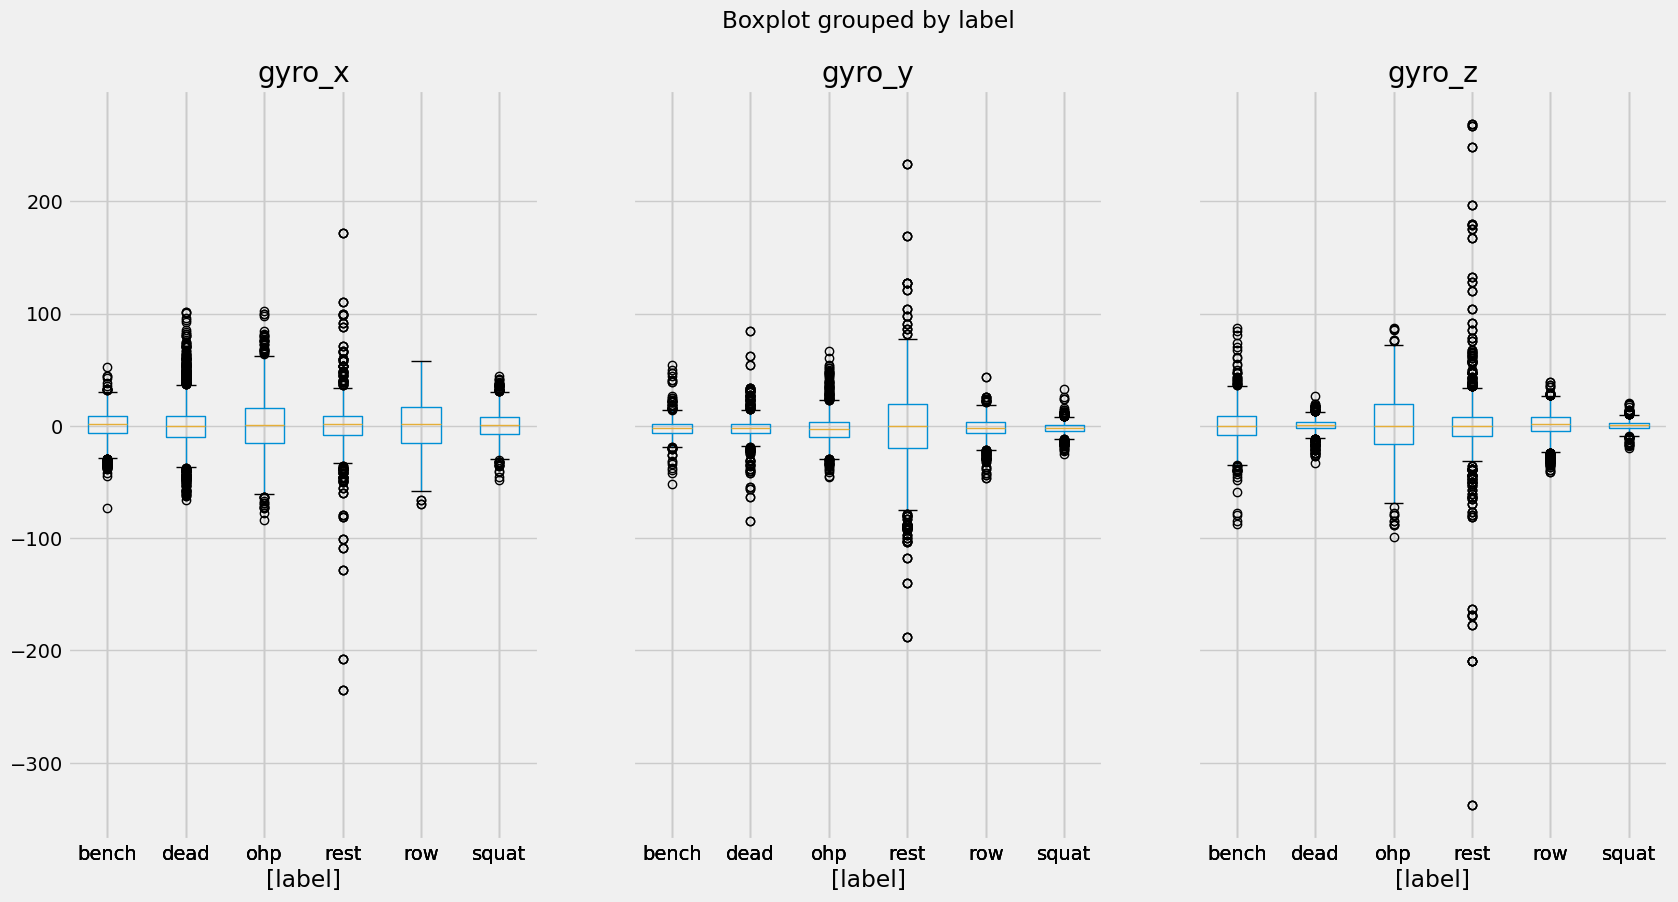

In [44]:
df[outlier_col[3:] +['label']].boxplot(by='label', figsize=(20,10),layout=(1,3))

In [45]:
def mark_outliers_iqr(dataset, col):
    
    dataset = dataset.copy()

    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    dataset[col + "_outlier"] = (dataset[col] < lower_bound) | (
        dataset[col] > upper_bound
    )

    return dataset

In [46]:
def plot_binary_outliers(dataset, col, outlier_col, reset_index):
    """ Plot outliers in case of a binary outlier score. Here, the col specifies the real data
    column and outlier_col the columns with a binary value (outlier or not).

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): Column that you want to plot
        outlier_col (string): Outlier column marked with true/false
        reset_index (bool): whether to reset the index for plotting
    """

    dataset = dataset.dropna(axis=0, subset=[col, outlier_col])
    dataset[outlier_col] = dataset[outlier_col].astype("bool")

    if reset_index:
        dataset = dataset.reset_index()

    fig, ax = plt.subplots()

    plt.xlabel("samples")
    plt.ylabel("value")

    # Plot non outliers in default color
    ax.plot(
        dataset.index[~dataset[outlier_col]],
        dataset[col][~dataset[outlier_col]],
        "+",
    )
    # Plot data points that are outliers in red
    ax.plot(
        dataset.index[dataset[outlier_col]],
        dataset[col][dataset[outlier_col]],
        "r+",
    )

    plt.legend(
        ["outlier " + col, "no outlier " + col],
        loc="upper center",
        ncol=2,
        fancybox=True,
        shadow=True,
    )
    plt.show()

In [47]:
col = 'acc_x'
dataset = mark_outliers_iqr(df, col)

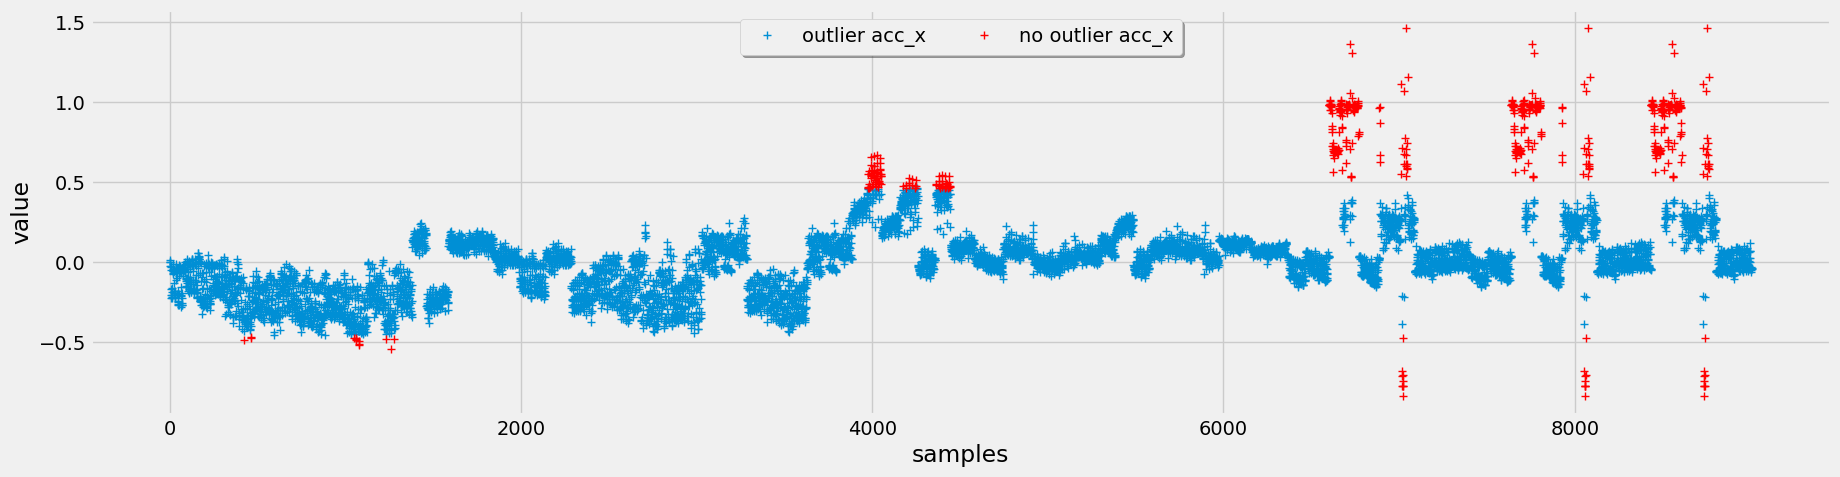

In [48]:
plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True)

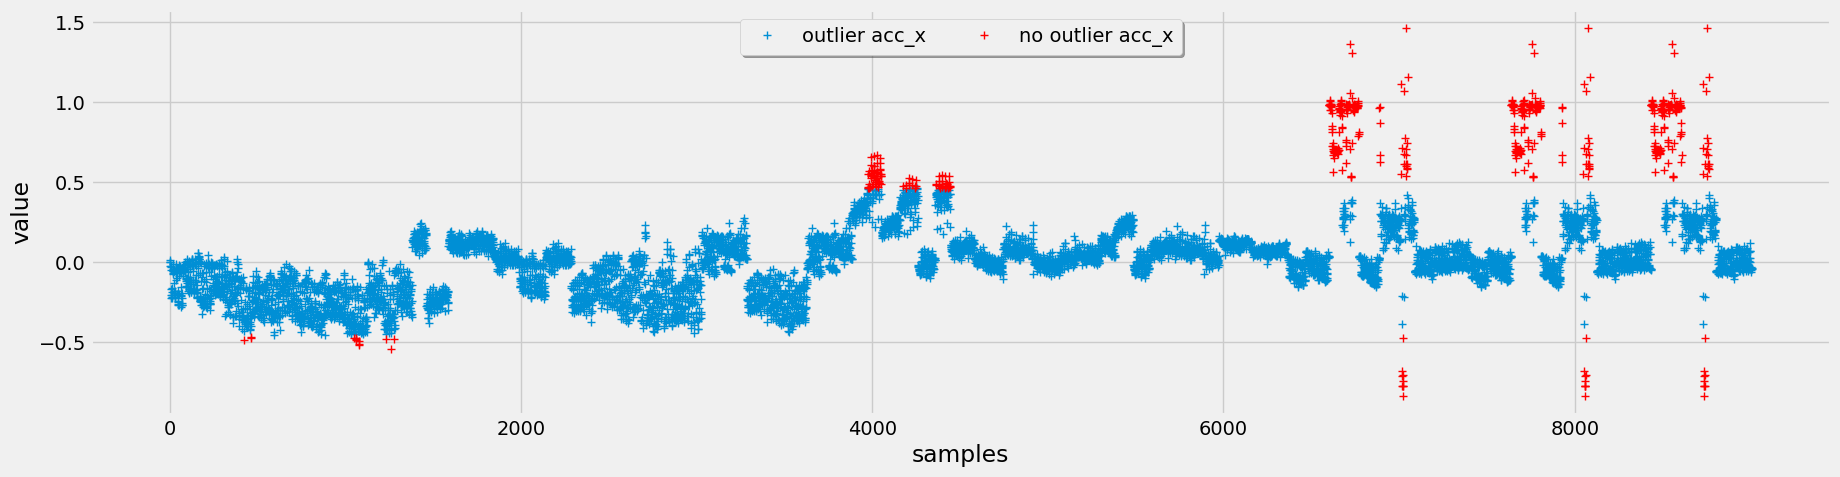

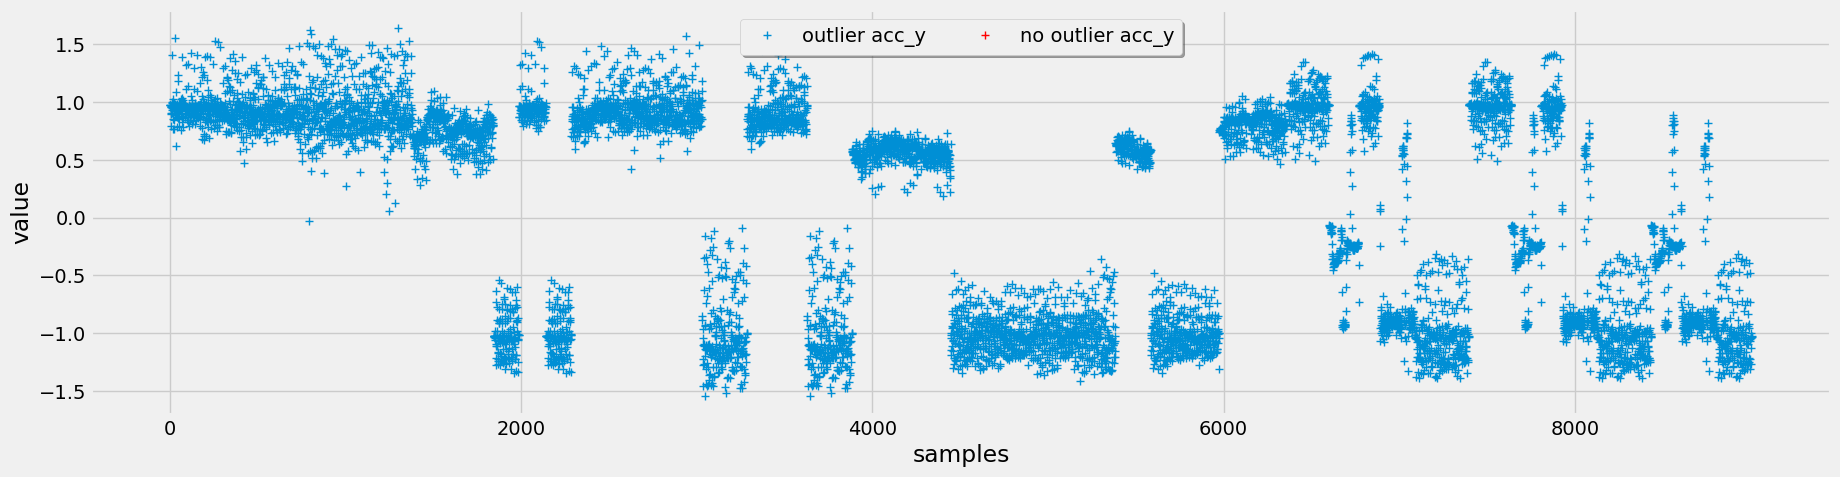

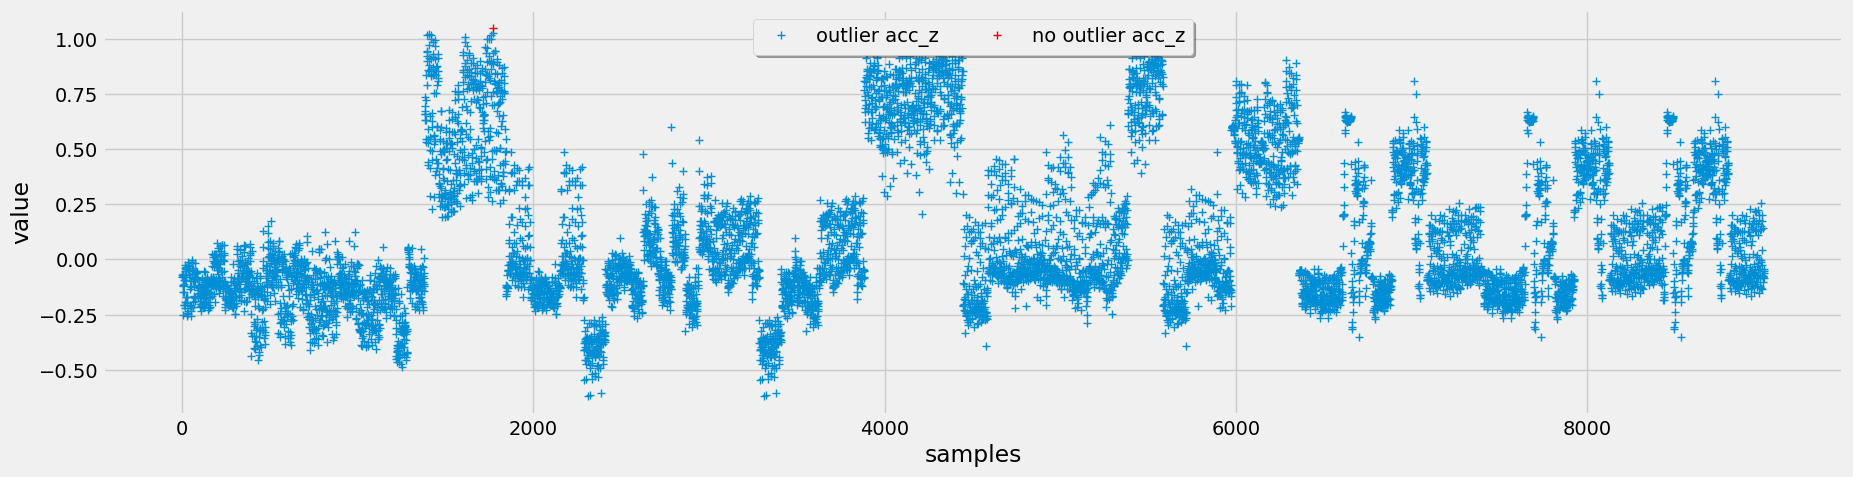

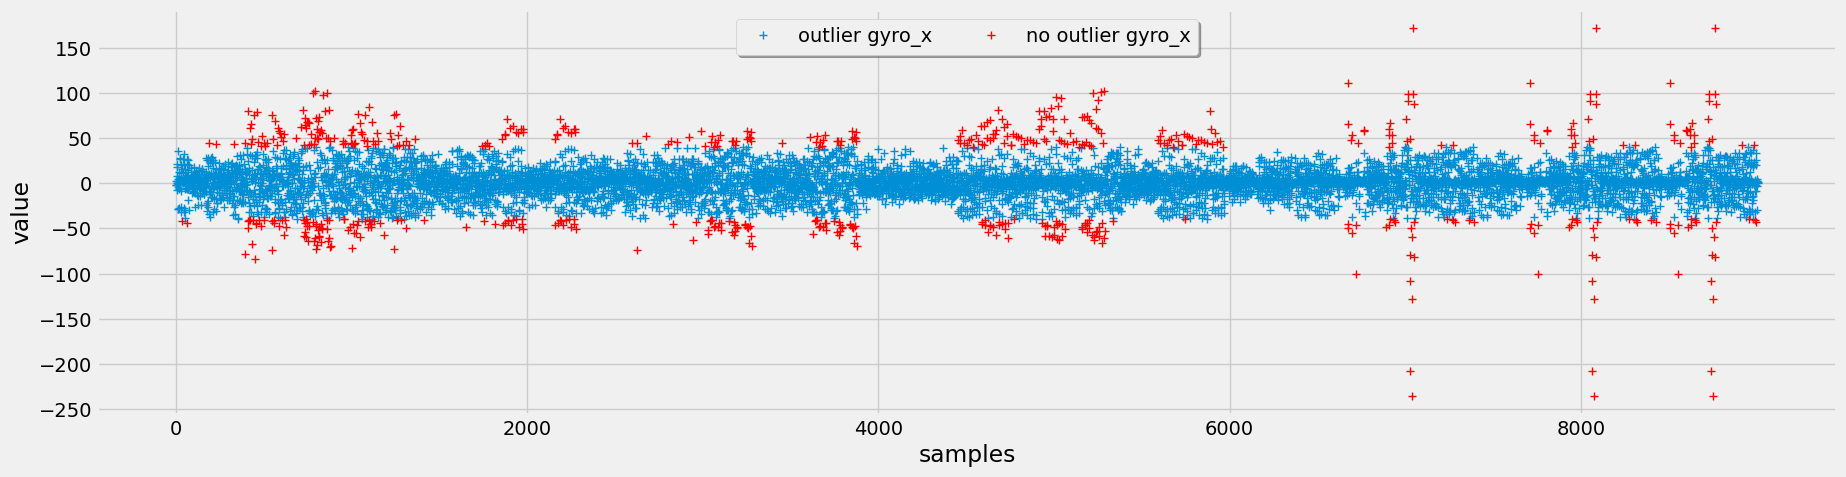

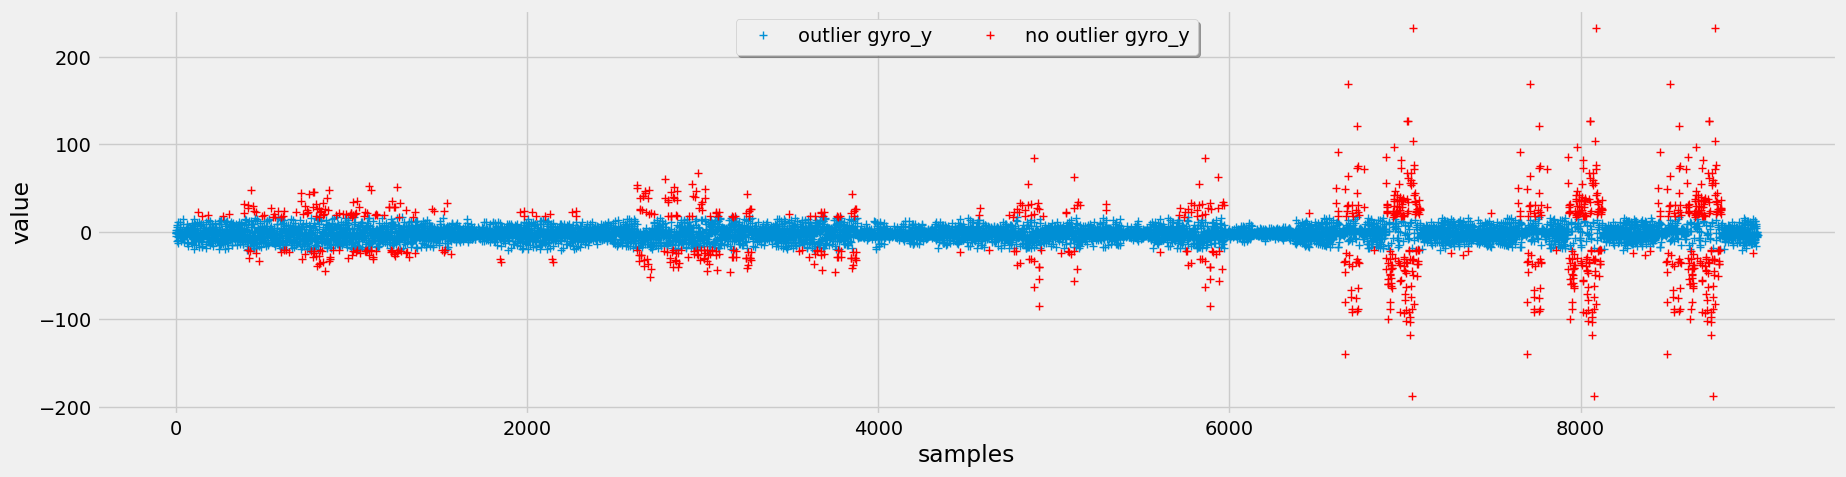

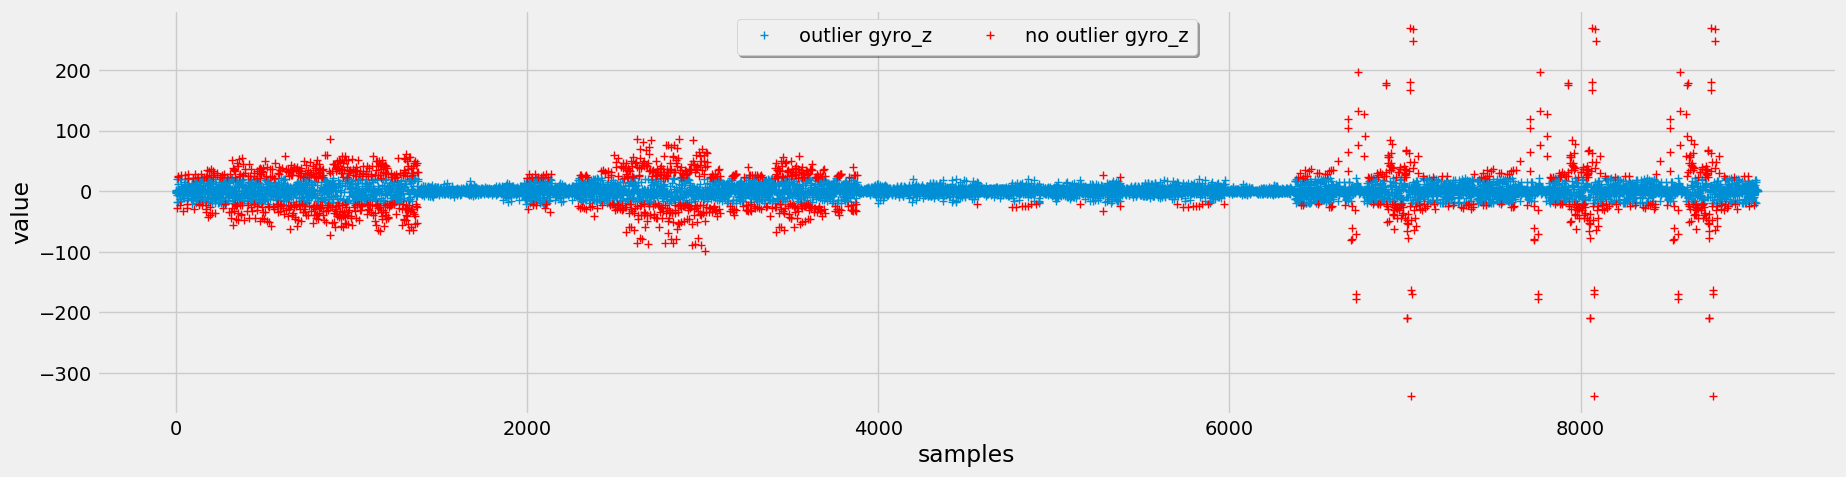

In [49]:
for col in outlier_col:
    dataset = mark_outliers_iqr(df, col)
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True)

/tmp/ipykernel_79162/869957398.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df[outlier_col[:3] +['label']].plot.hist(by='label', figsize=(20,10),layout=(3,3))
/tmp/ipykernel_79162/869957398.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df[outlier_col[3:] +['label']].plot.hist(by='label', figsize=(20,10),layout=(3,3))


array([[<Axes: title={'center': 'bench'}, ylabel='Frequency'>,
        <Axes: title={'center': 'dead'}, ylabel='Frequency'>,
        <Axes: title={'center': 'ohp'}, ylabel='Frequency'>],
       [<Axes: title={'center': 'rest'}, ylabel='Frequency'>,
        <Axes: title={'center': 'row'}, ylabel='Frequency'>,
        <Axes: title={'center': 'squat'}, ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>]], dtype=object)

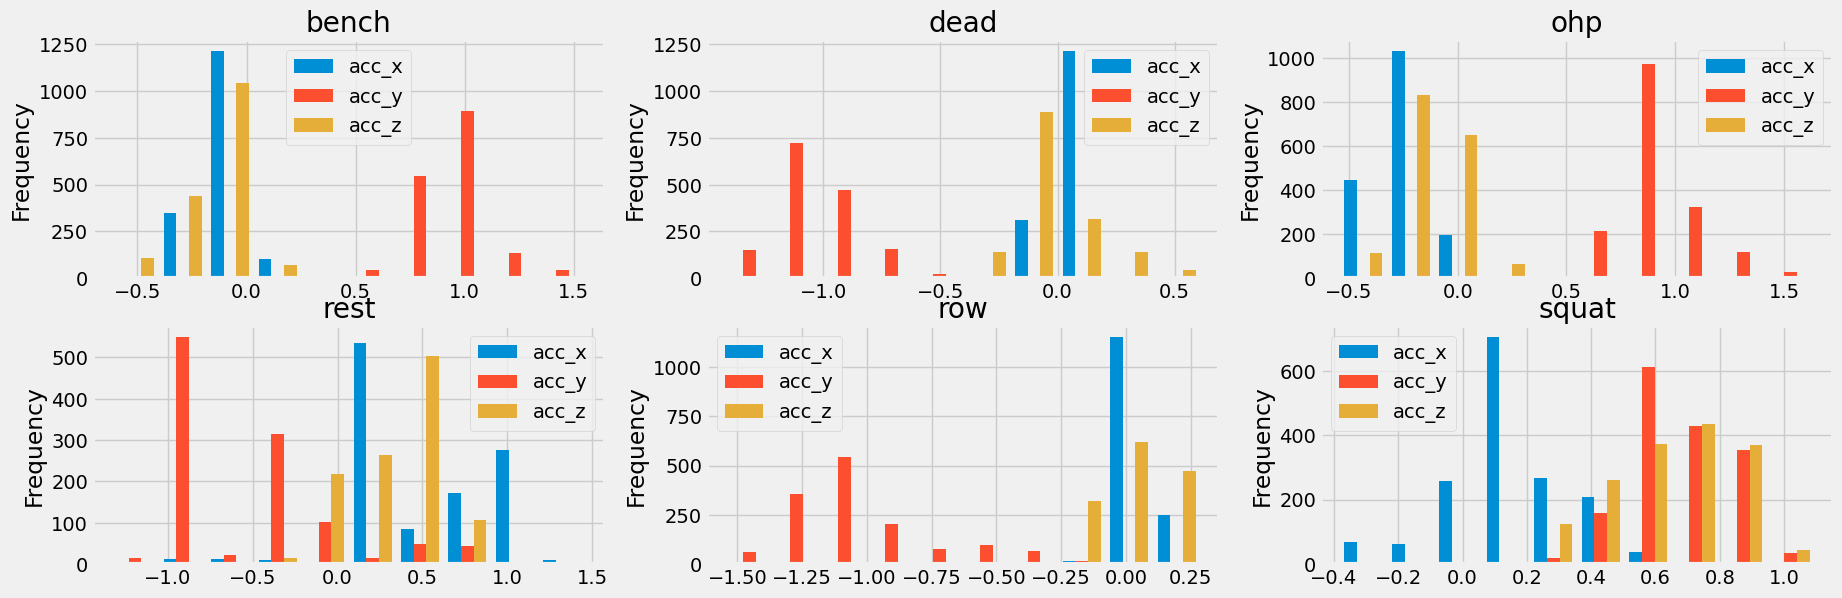

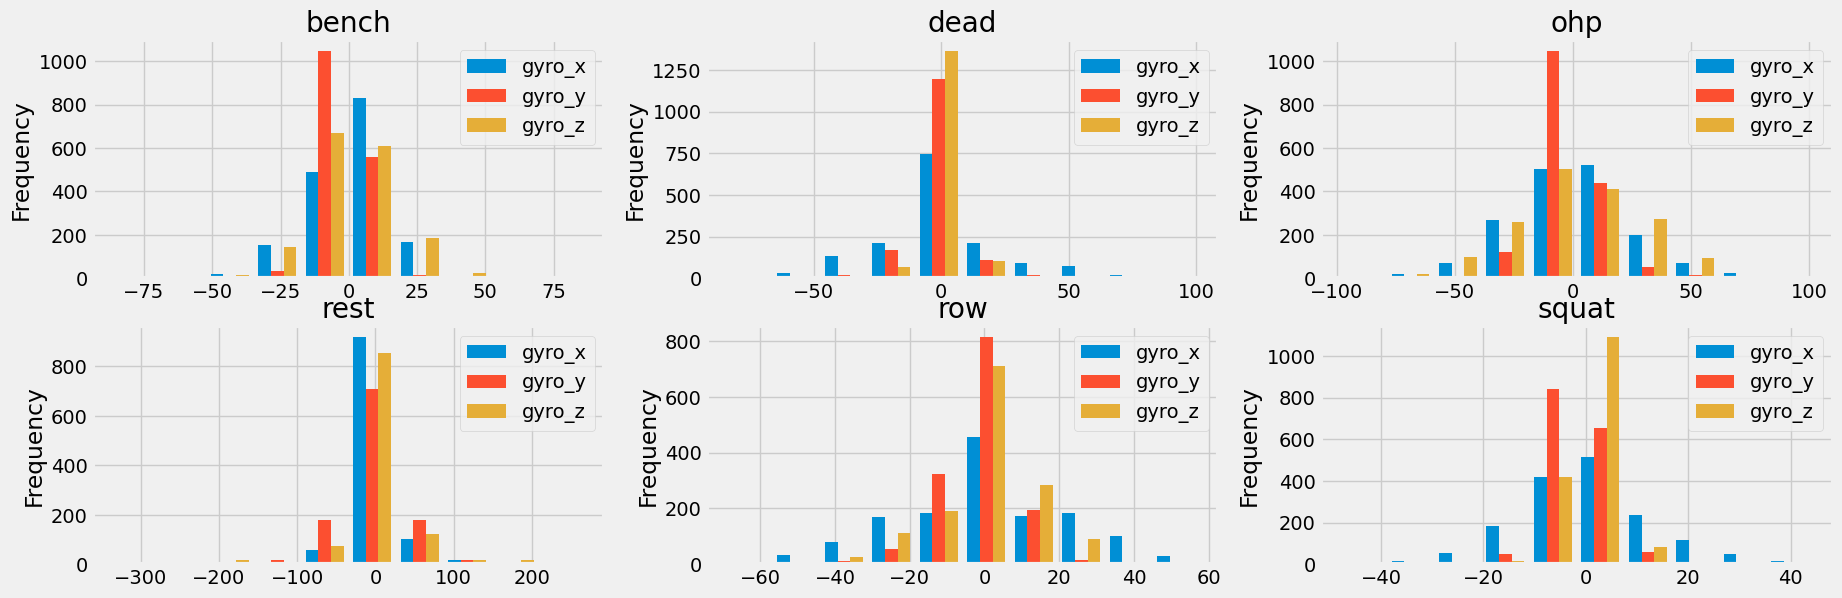

In [50]:
df[outlier_col[:3] +['label']].plot.hist(by='label', figsize=(20,10),layout=(3,3))
df[outlier_col[3:] +['label']].plot.hist(by='label', figsize=(20,10),layout=(3,3))

In [51]:
def mark_outliers_chauvenet(dataset, col, C=2):
    """Finds outliers in the specified column of datatable and adds a binary column with
    the same name extended with '_outlier' that expresses the result per data point.
    
    Taken from: https://github.com/mhoogen/ML4QS/blob/master/Python3Code/Chapter3/OutlierDetection.py

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to
        C (int, optional): Degree of certainty for the identification of outliers given the assumption 
                           of a normal distribution, typicaly between 1 - 10. Defaults to 2.

    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column 
        indicating whether the value is an outlier or not.
    """

    dataset = dataset.copy()
    # Compute the mean and standard deviation.
    mean = dataset[col].mean()
    std = dataset[col].std()
    N = len(dataset.index)
    criterion = 1.0 / (C * N)

    # Consider the deviation for the data points.
    deviation = abs(dataset[col] - mean) / std

    # Express the upper and lower bounds.
    low = -deviation / math.sqrt(C)
    high = deviation / math.sqrt(C)
    prob = []
    mask = []

    # Pass all rows in the dataset.
    for i in range(0, len(dataset.index)):
        # Determine the probability of observing the point
        prob.append(
            1.0 - 0.5 * (scipy.special.erf(high.iloc[i]) - scipy.special.erf(low.iloc[i]))
        )
        # And mark as an outlier when the probability is below our criterion.
        mask.append(prob[i] < criterion)
    dataset[col + "_outlier"] = mask
    return dataset

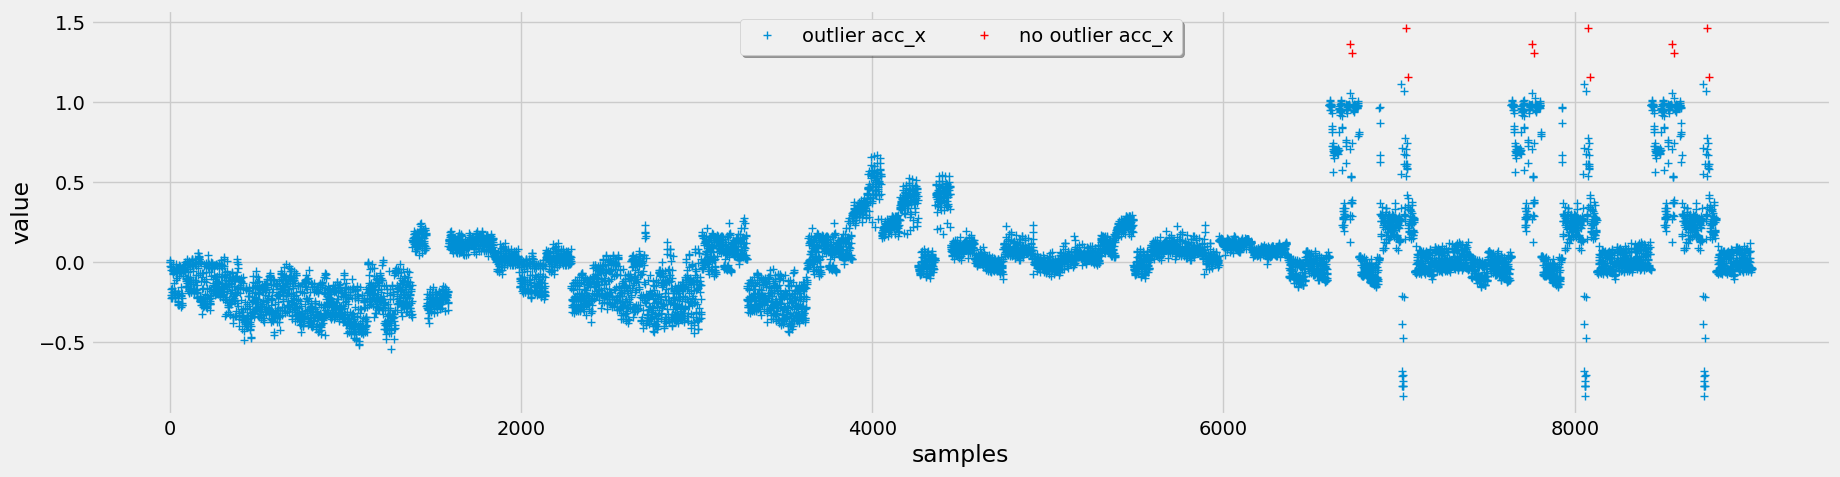

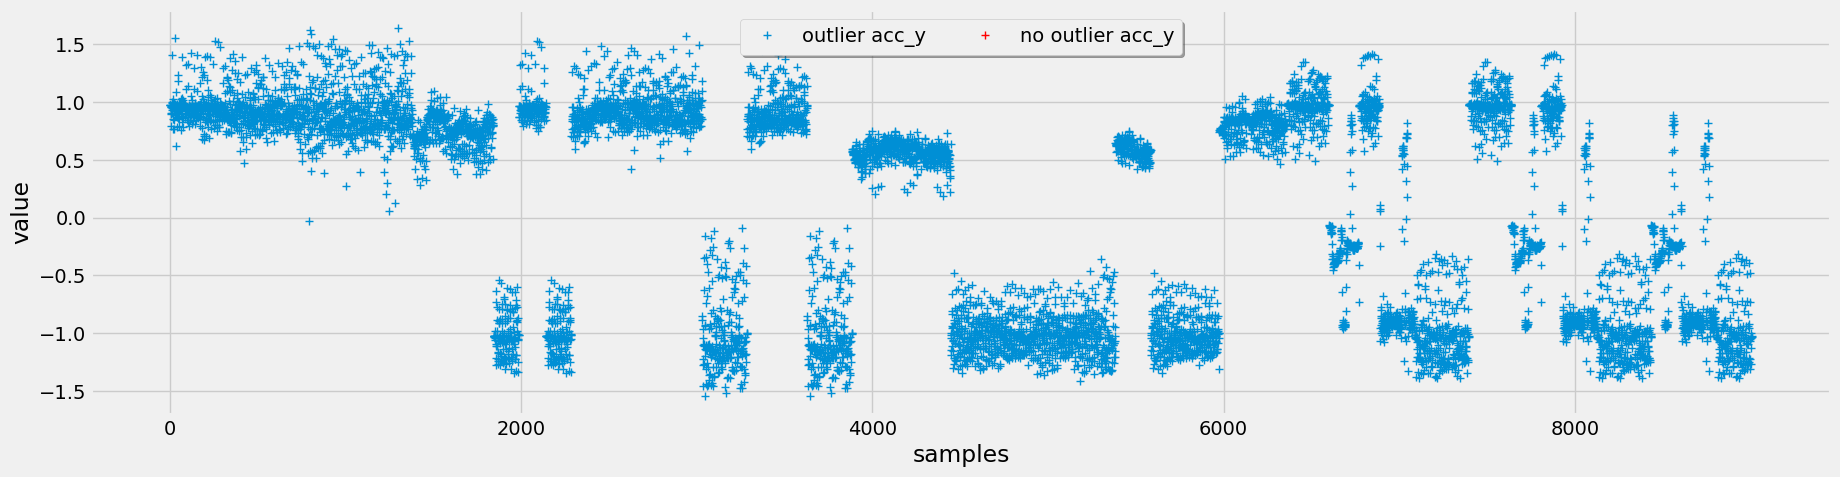

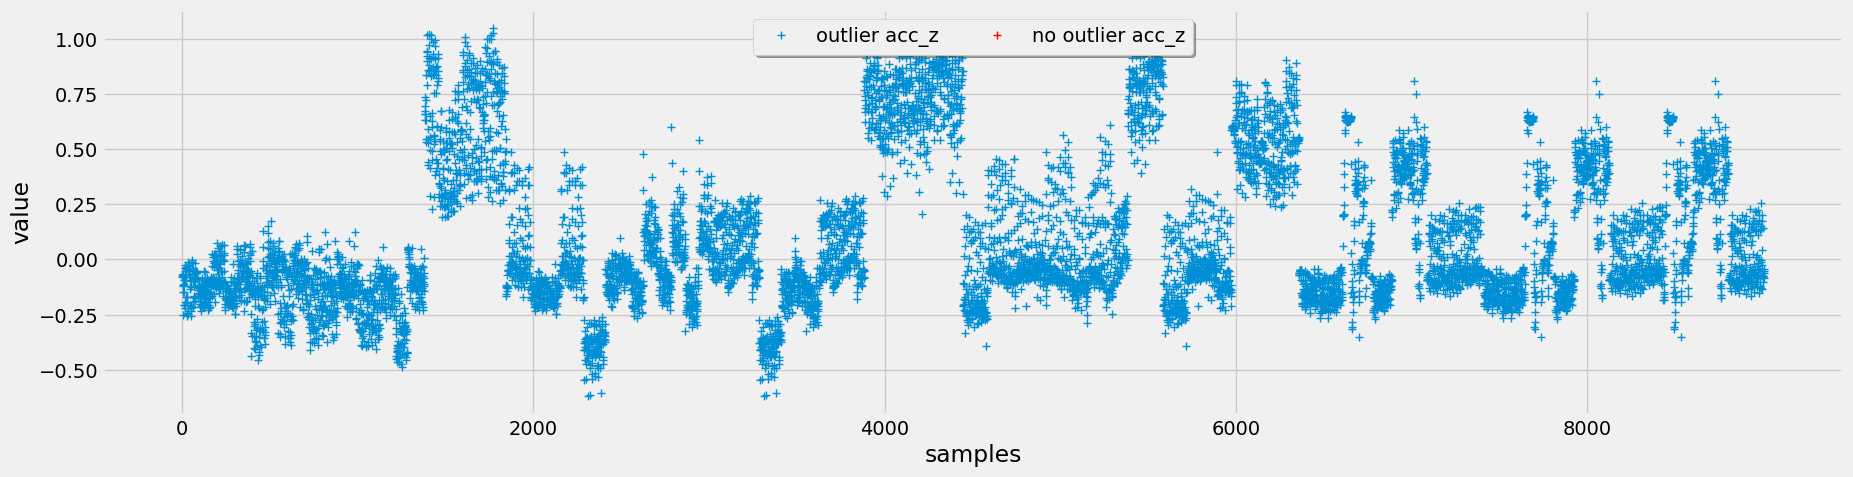

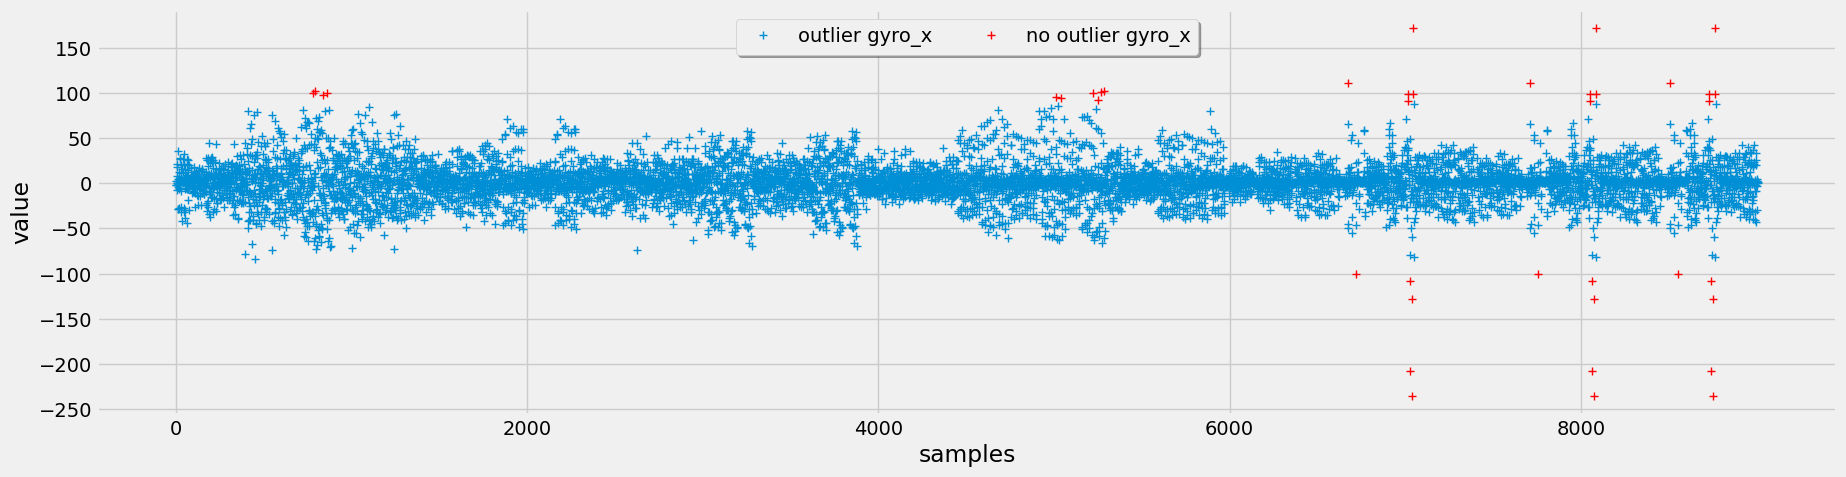

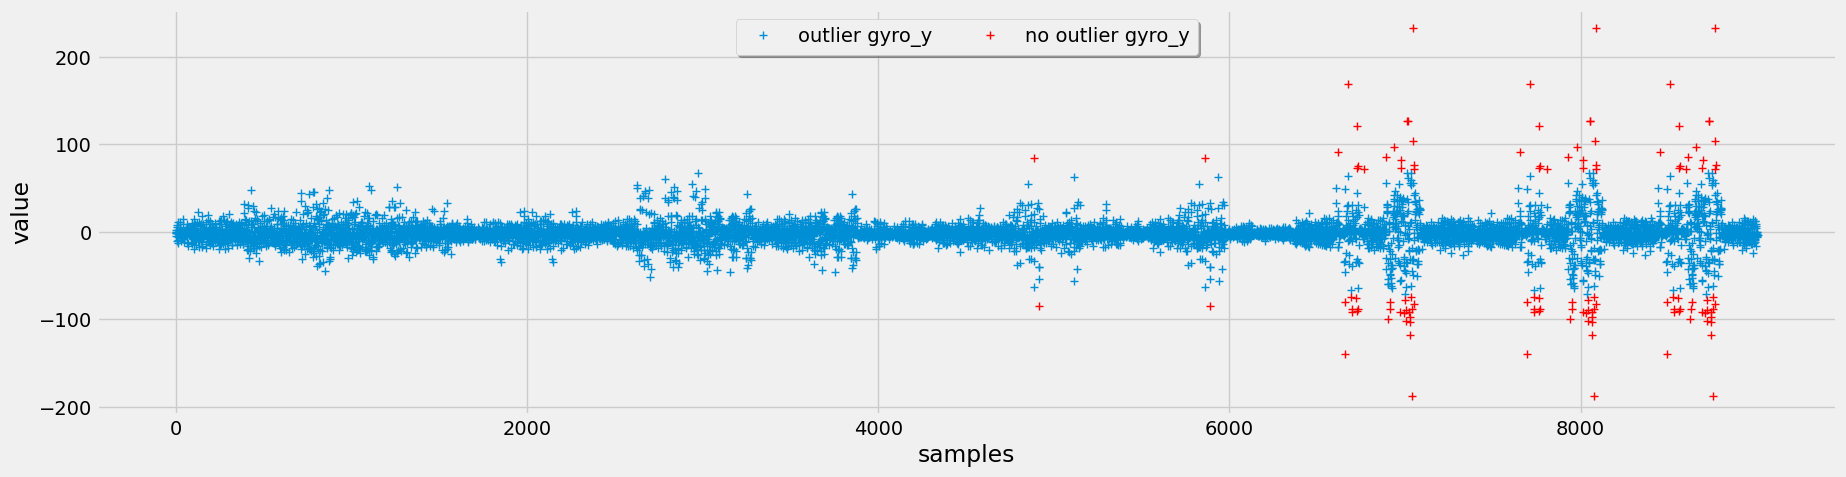

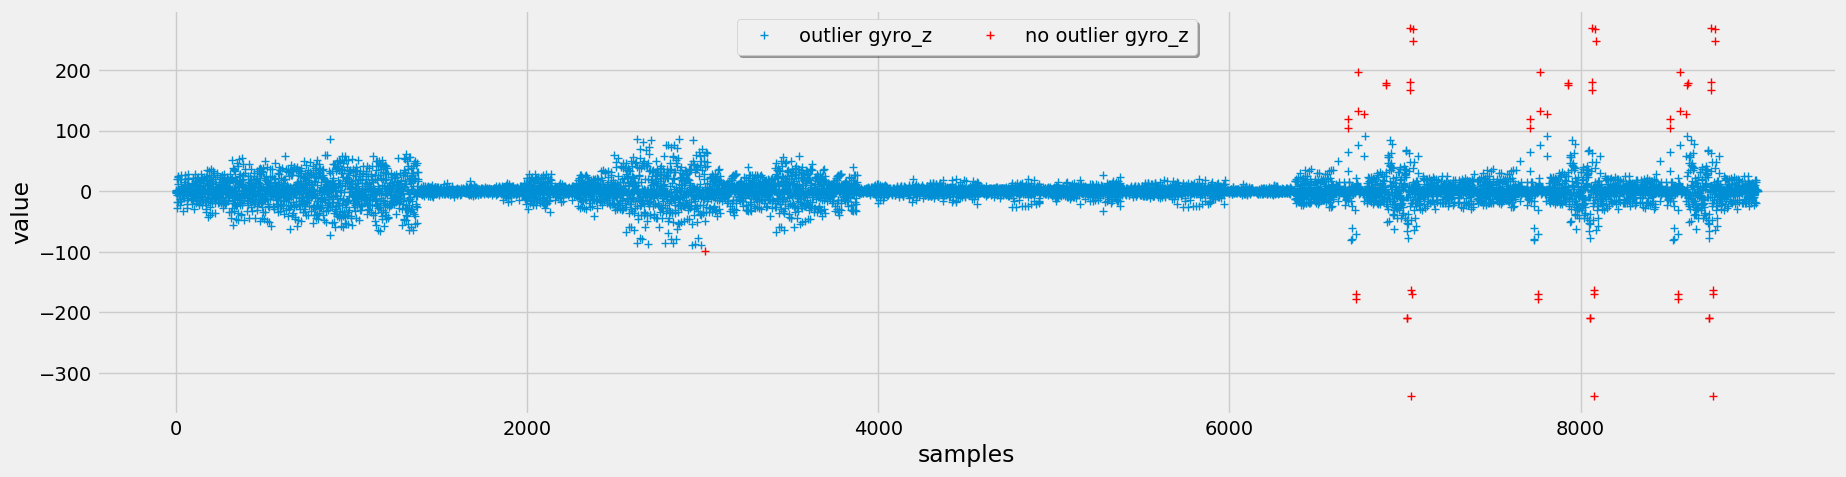

In [52]:
for col in outlier_col:
    dataset = mark_outliers_chauvenet(df, col)
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True)

In [53]:
def mark_outliers_lof(dataset, columns, n=20):
    """Mark values as outliers using LOF

    Args:
        dataset (pd.DataFrame): The dataset
        columns (list): The columns you want to apply outlier detection to
        n (int, optional): n_neighbors. Defaults to 20.
    
    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column
        indicating whether the value is an outlier or not.
    """
    
    dataset = dataset.copy()

    lof = LocalOutlierFactor(n_neighbors=n)
    data = dataset[columns]
    outliers = lof.fit_predict(data)
    X_scores = lof.negative_outlier_factor_

    dataset["outlier_lof"] = outliers == -1
    return dataset, outliers, X_scores

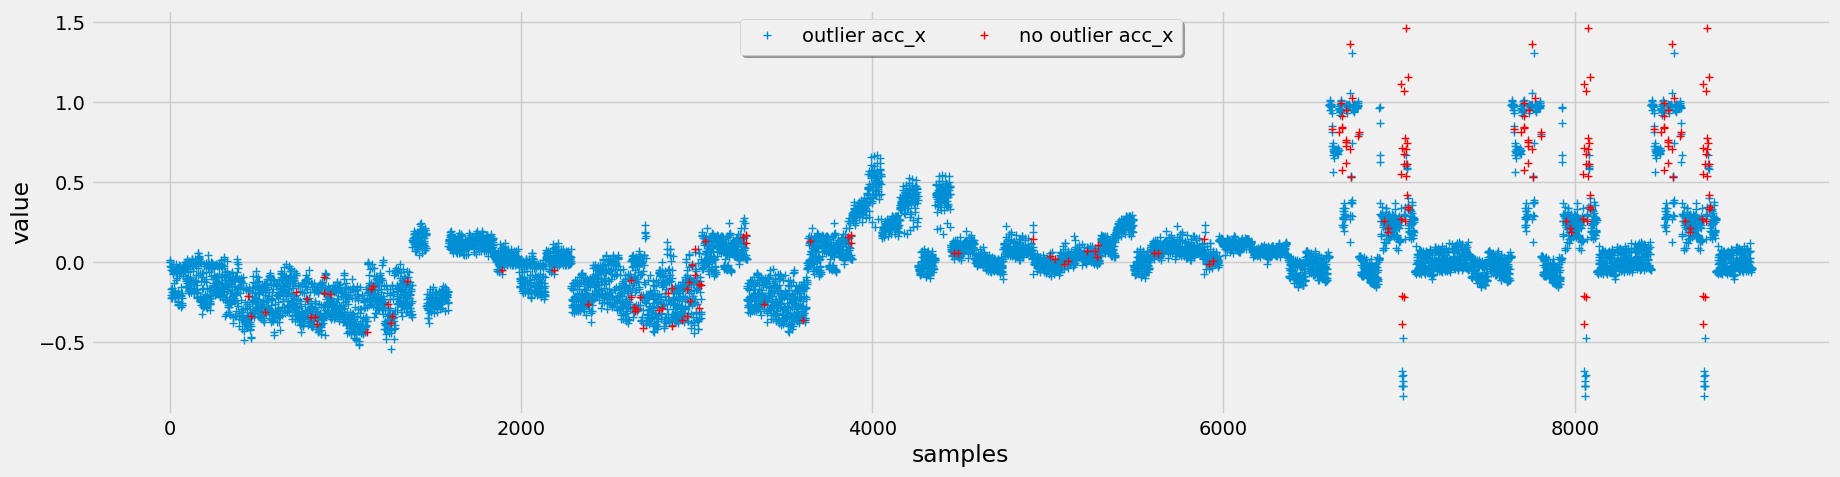

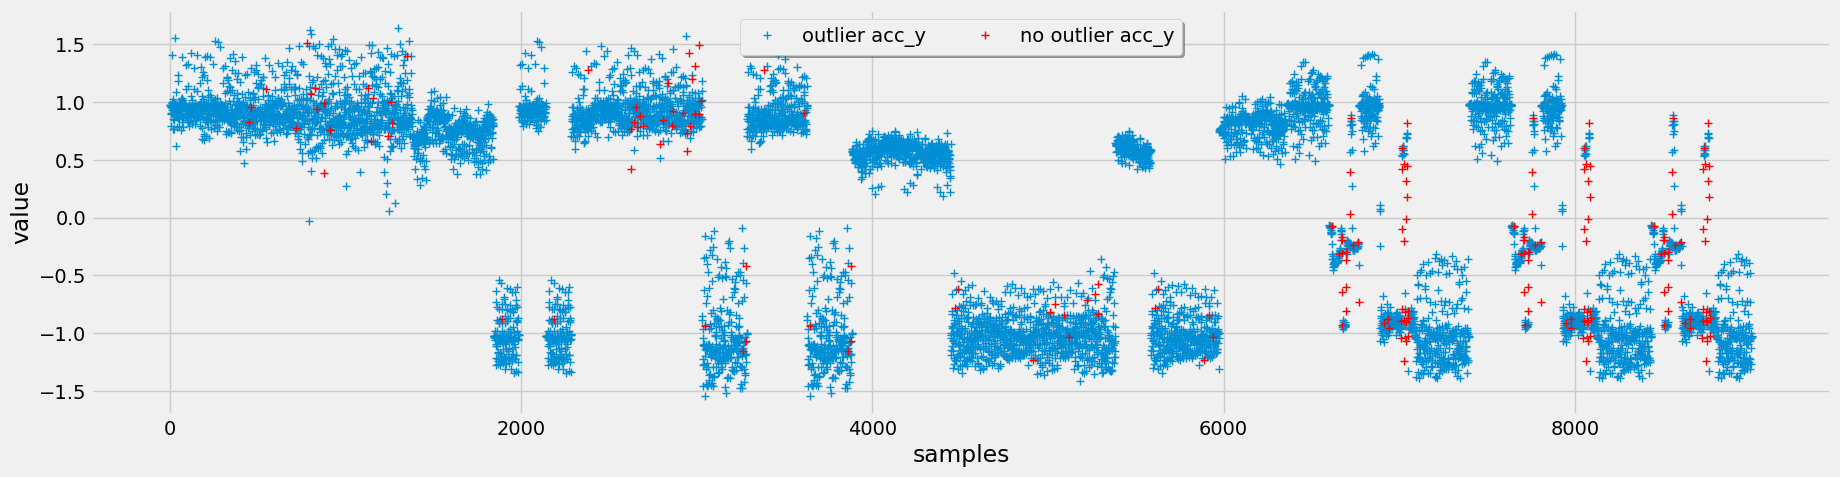

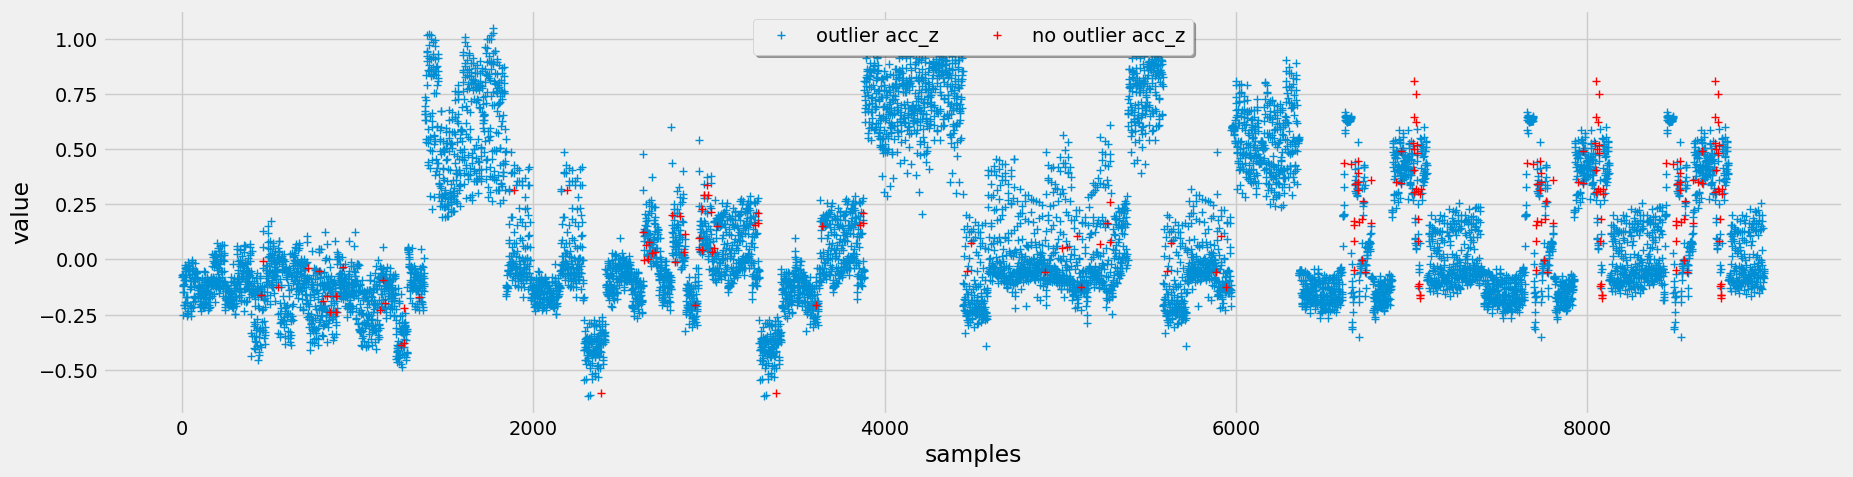

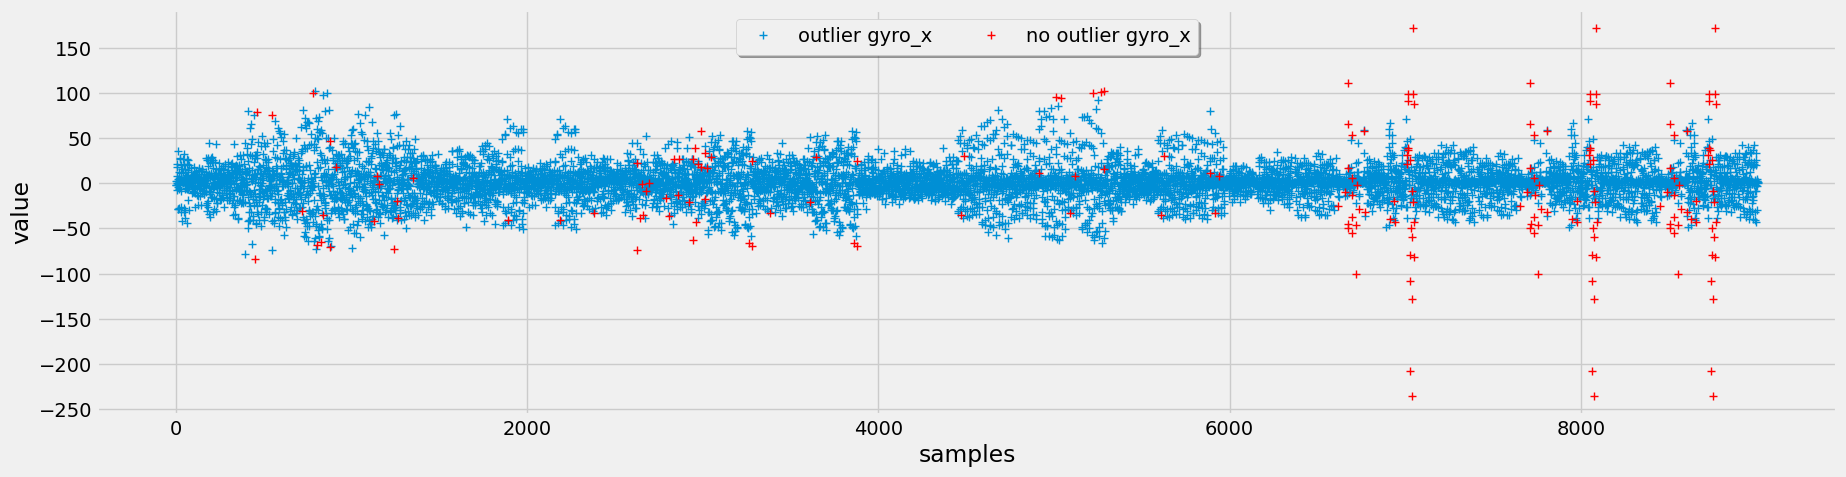

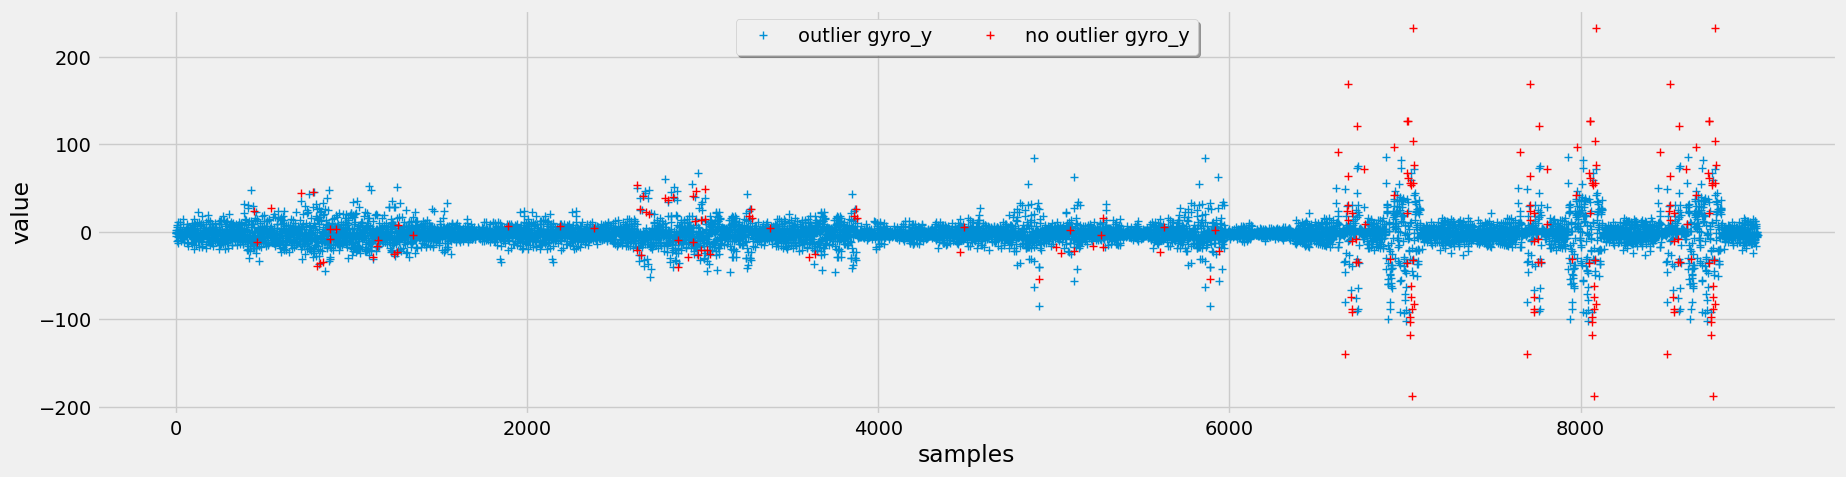

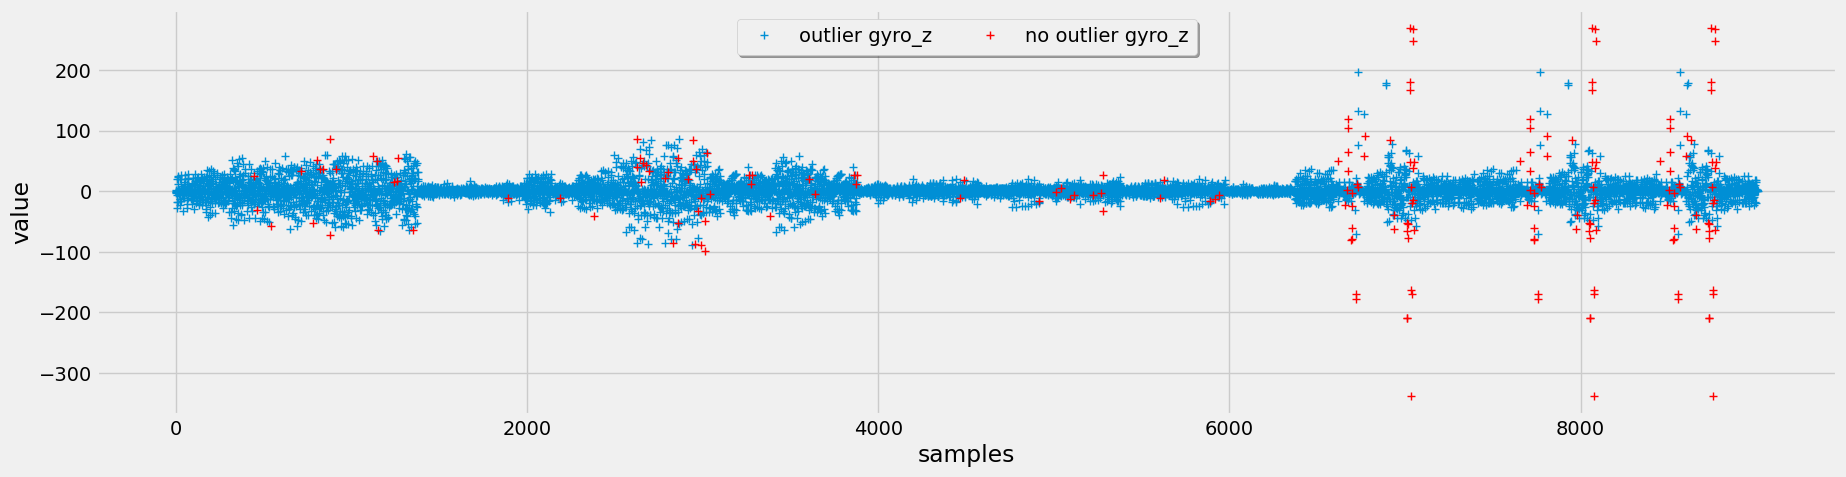

In [54]:
dataset, outliers, X_scores = mark_outliers_lof(df, outlier_col)
for col in outlier_col:
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= 'outlier_lof', reset_index=True)

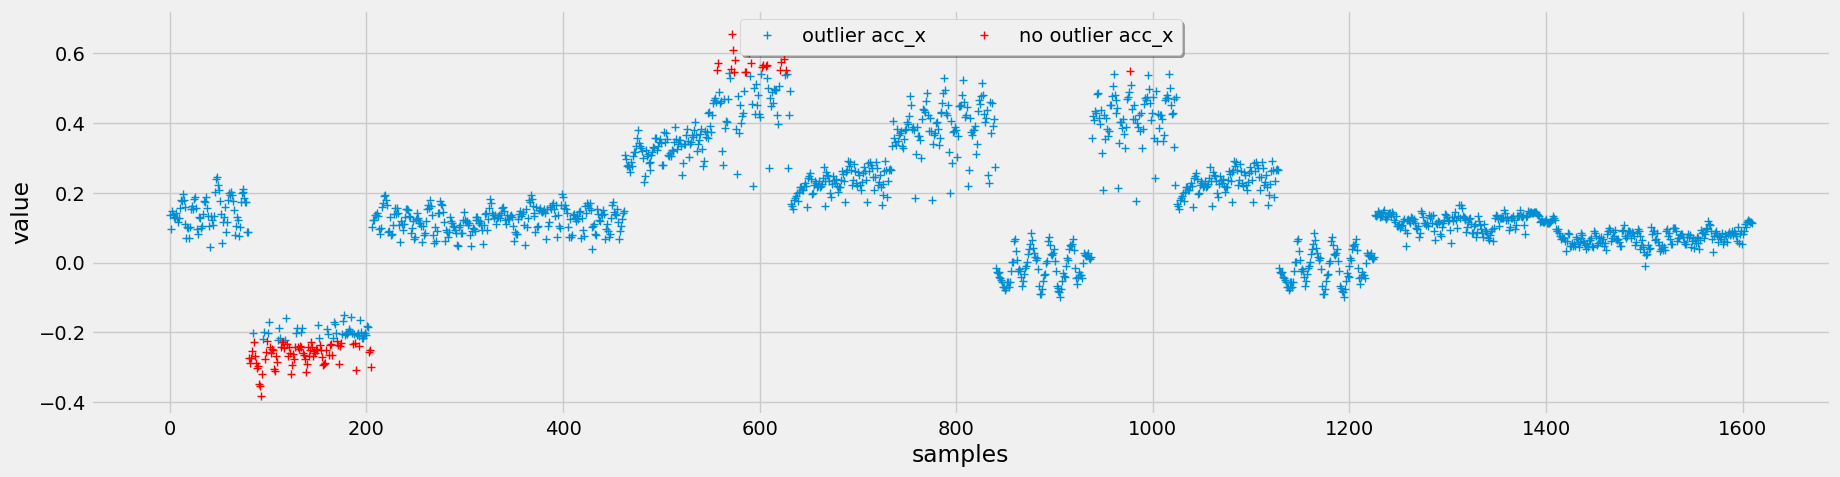

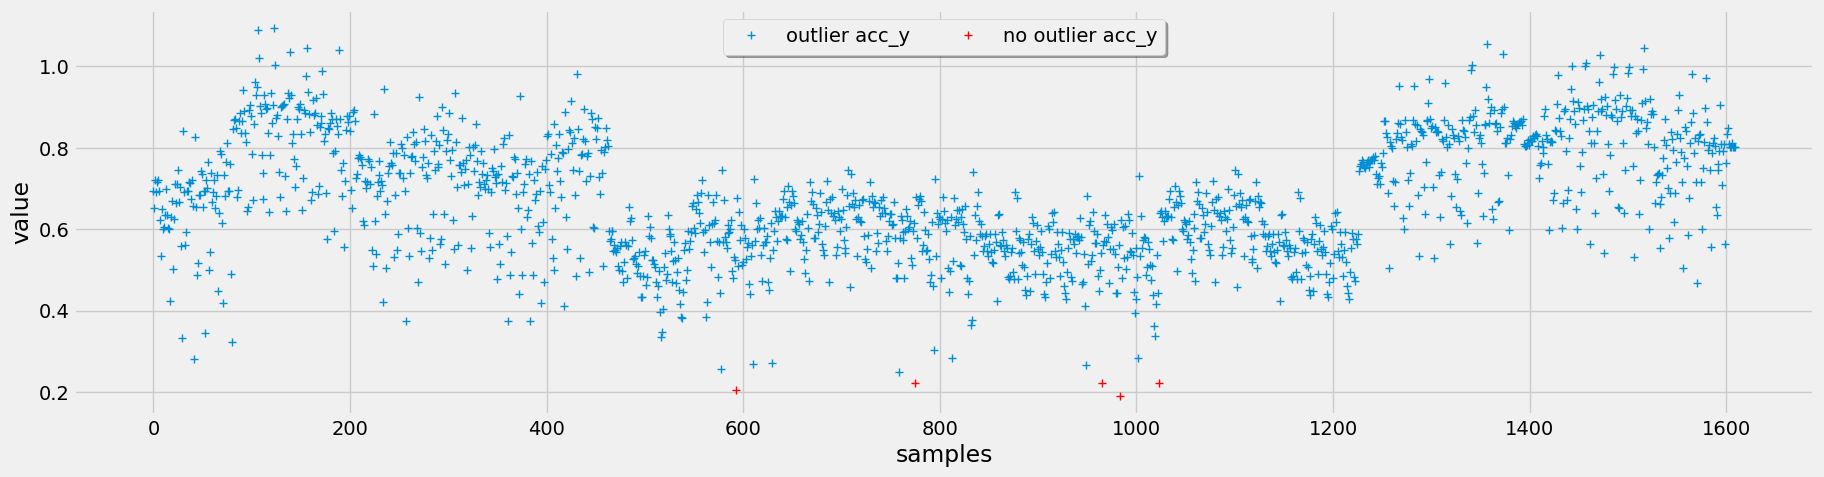

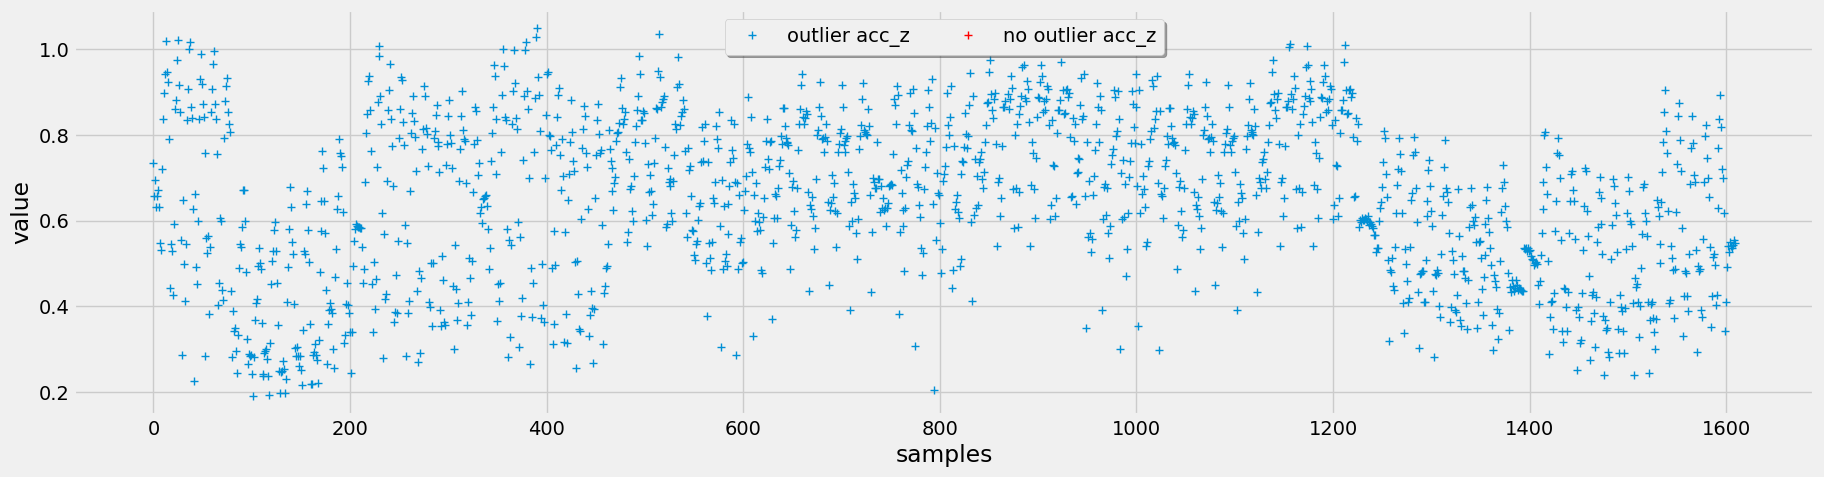

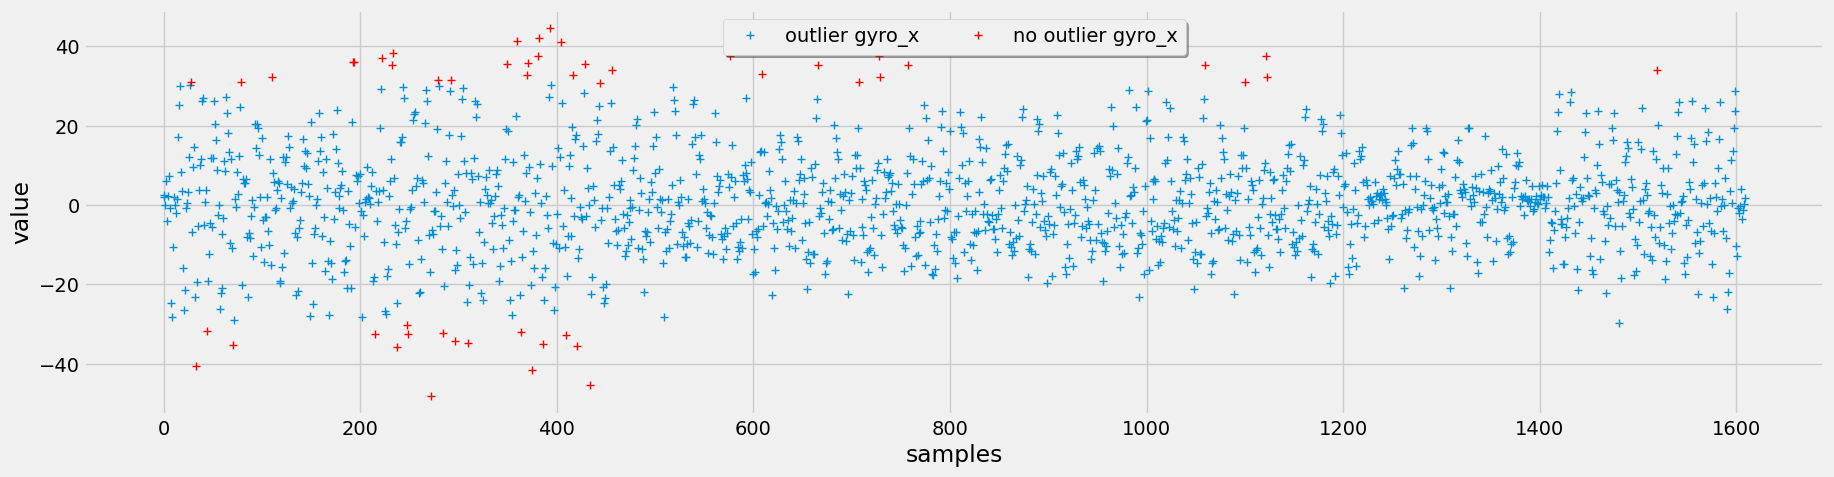

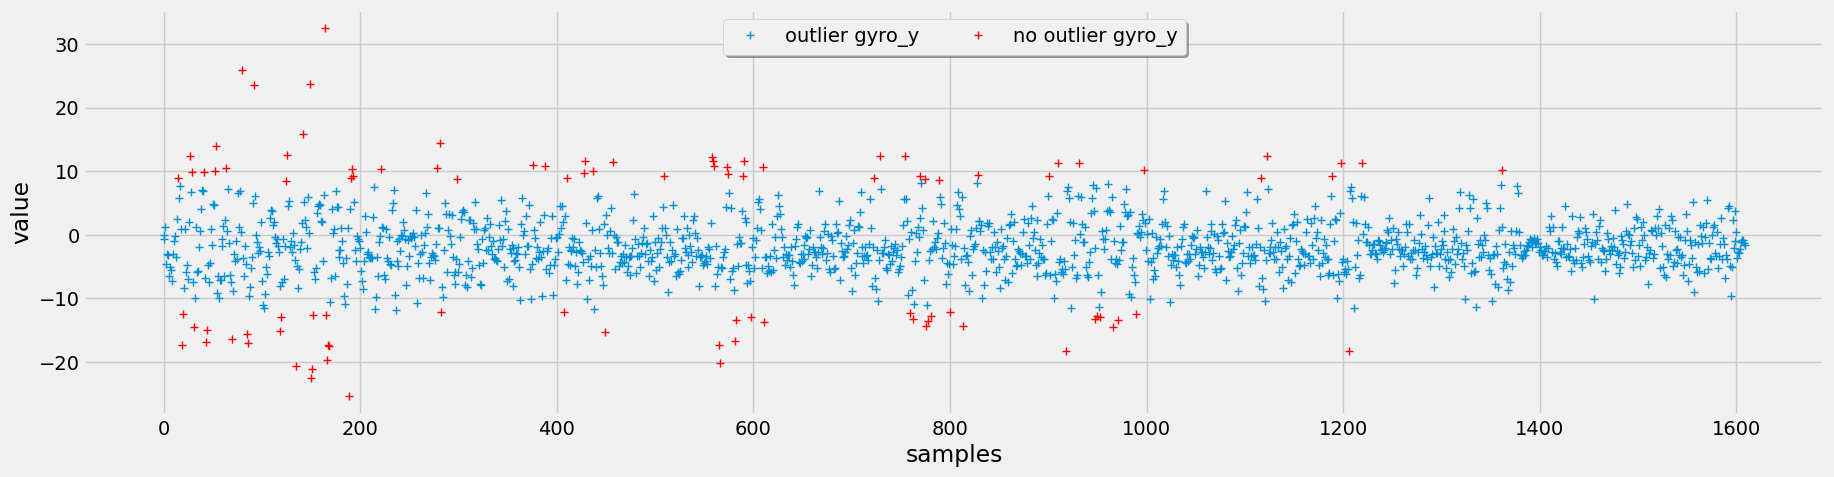

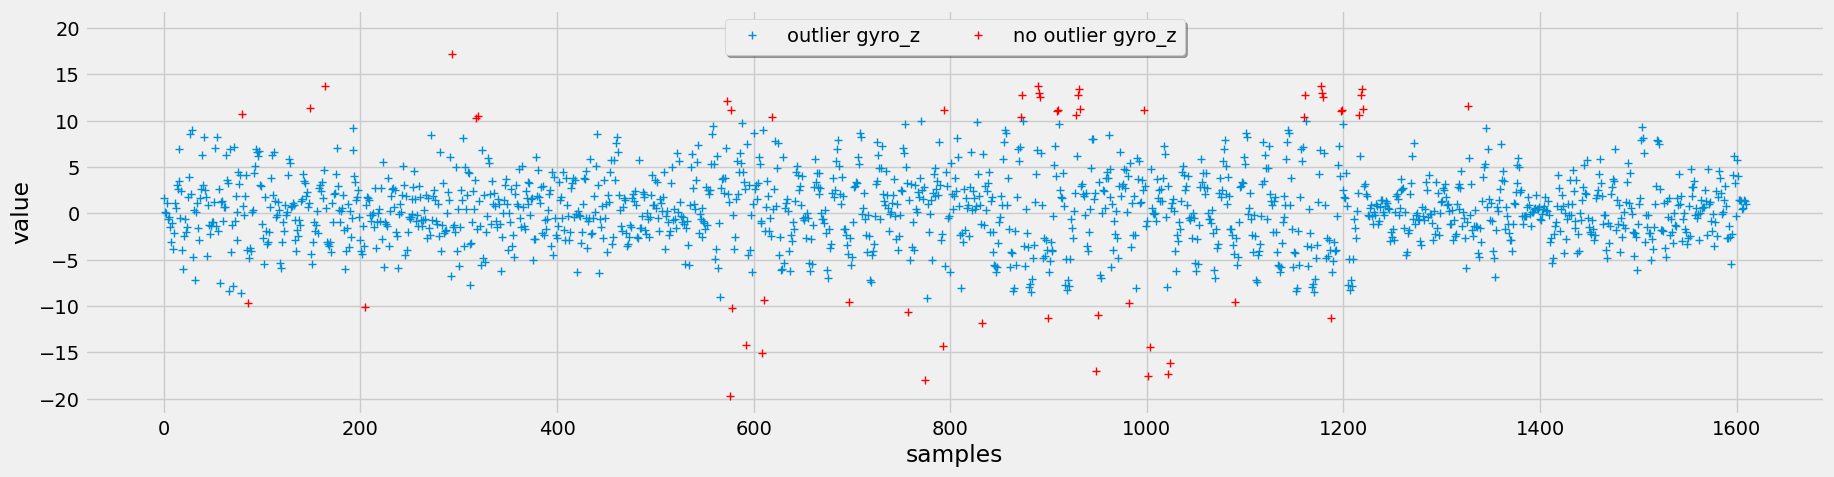

In [55]:
label = 'squat'

for col in outlier_col:
    dataset = mark_outliers_iqr(df[df['label'] == label], col)
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True )

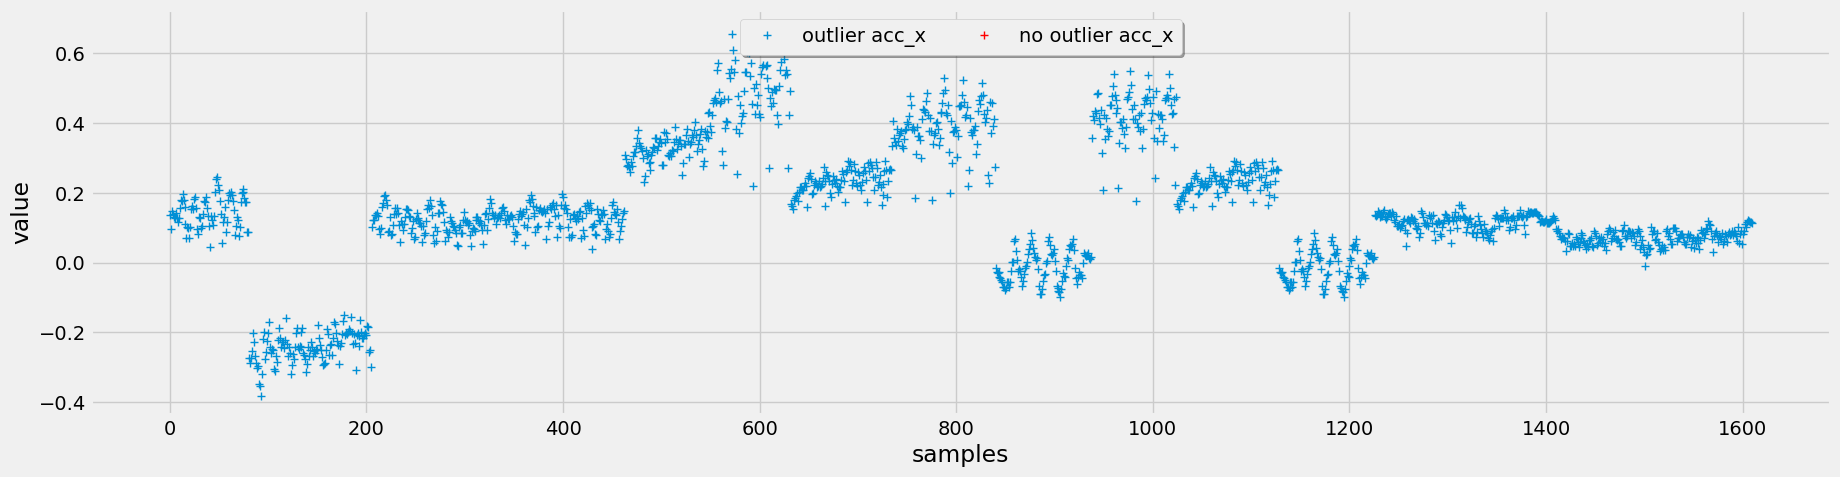

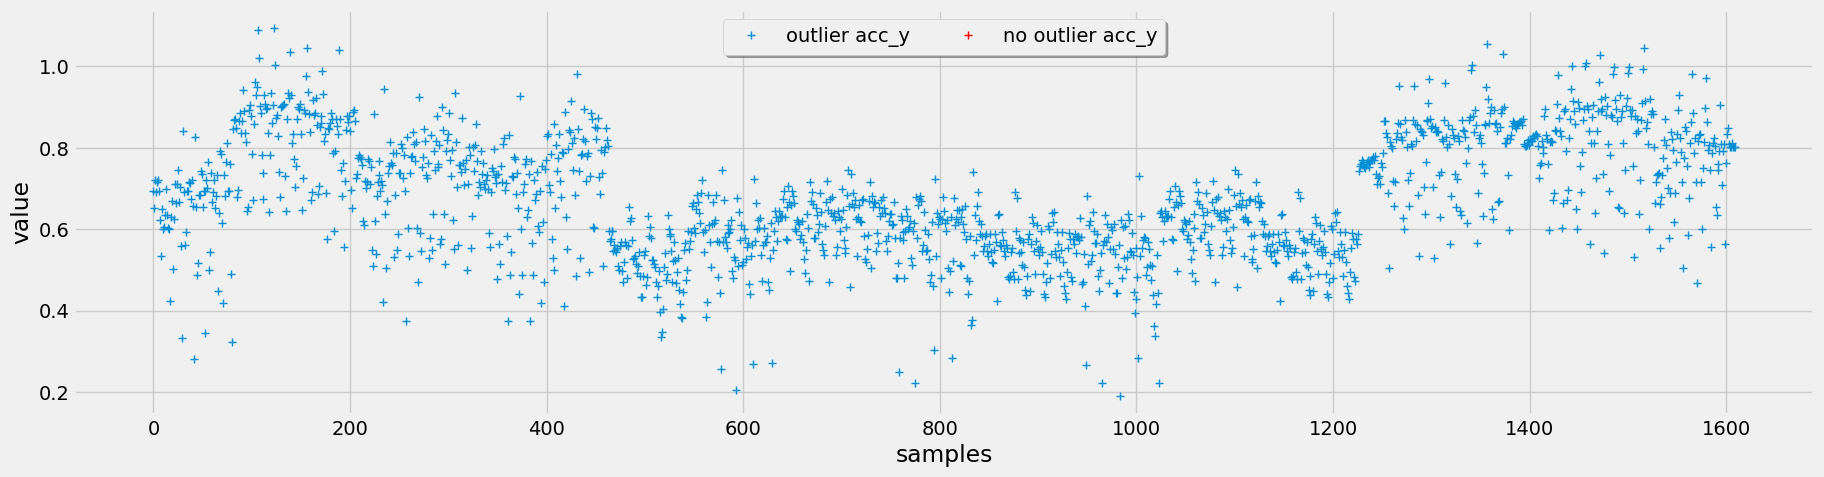

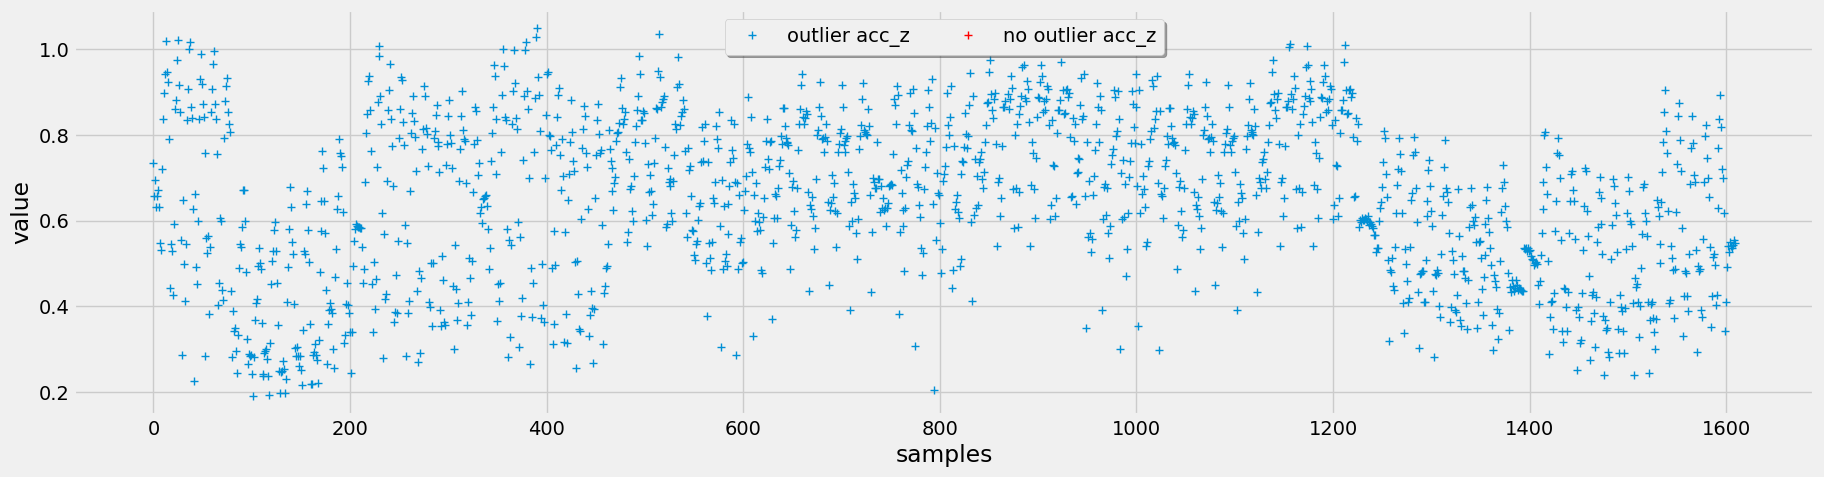

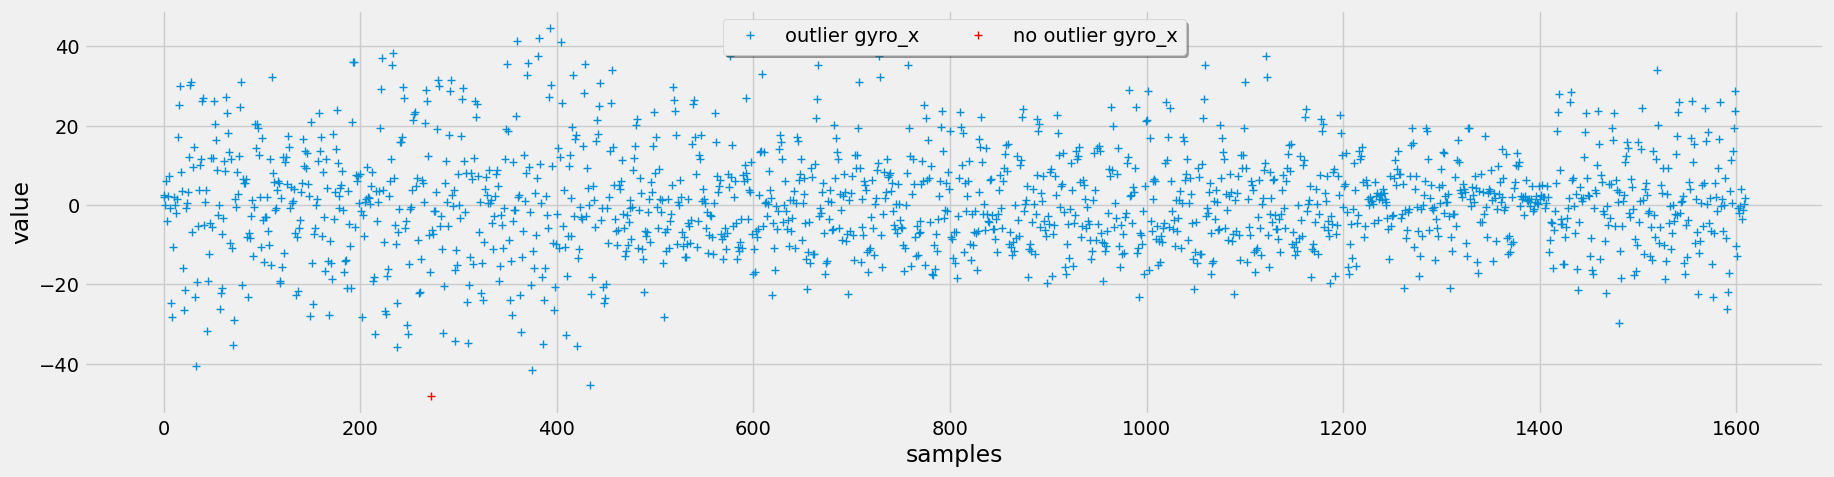

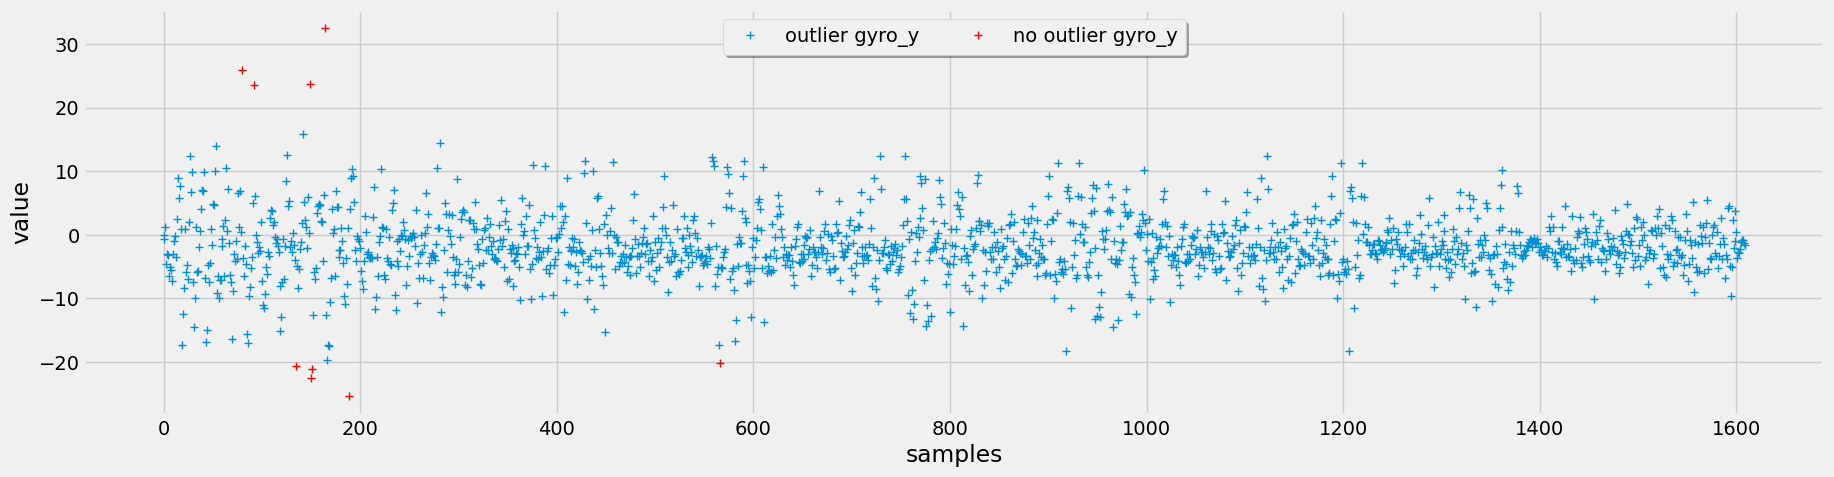

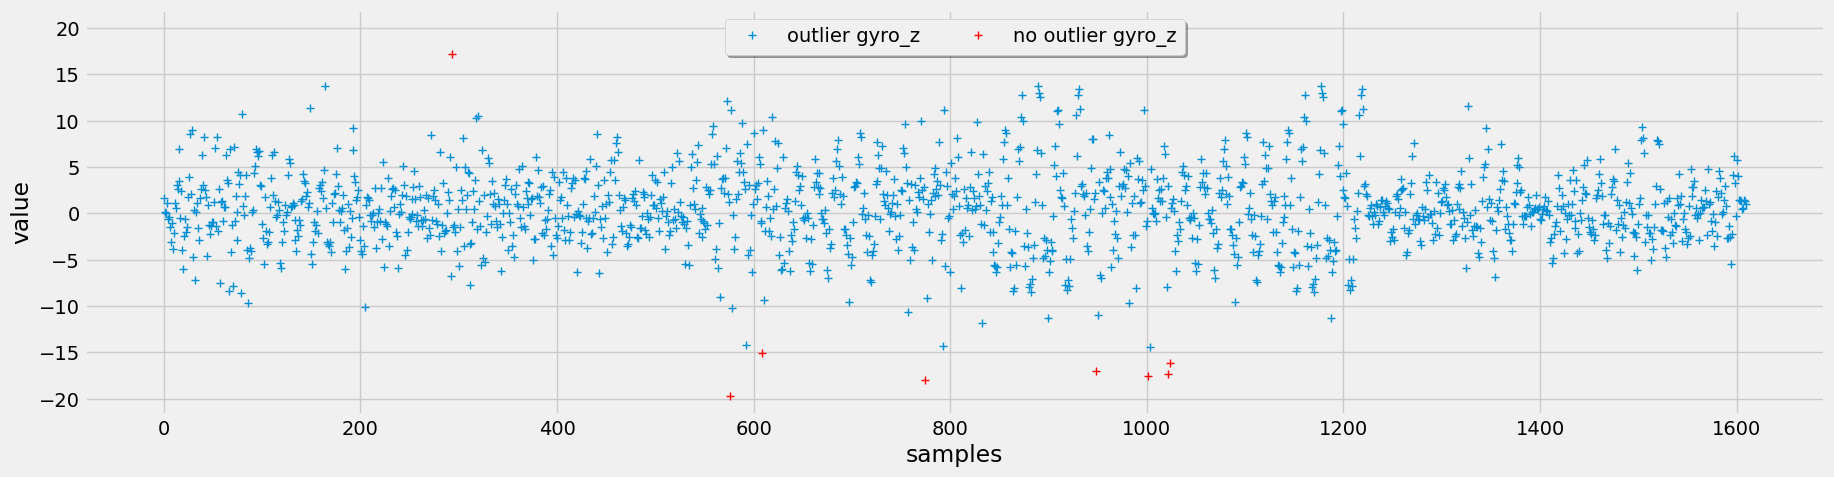

In [56]:
label = 'squat'

for col in outlier_col:
    dataset = mark_outliers_chauvenet(df[df['label'] == label], col)
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True )

In [57]:
col = 'gyro_z'
dataset = mark_outliers_chauvenet(dataset=df,col=col)
dataset[dataset["gyro_z_outlier"]]
dataset.loc[dataset["gyro_z_outlier"], "gyro_z"] = np.nan

In [58]:
outliers_removed_df = df.copy()
for col in outlier_col:
    for label in df['label'].unique():
        dataset = mark_outliers_chauvenet(df[df['label'] == label], col)

        dataset.loc[dataset[col + "_outlier"], col] = np.nan

        outliers_removed_df.loc[(outliers_removed_df['label'] == label),col] = dataset[col]

        n_outliers = len(dataset) - len(dataset[col].dropna())
        print(f"Removed {n_outliers} outliers from column {col} for label {label}")

Removed 0 outliers from column acc_x for label bench
Removed 2 outliers from column acc_x for label ohp
Removed 0 outliers from column acc_x for label squat
Removed 2 outliers from column acc_x for label dead
Removed 0 outliers from column acc_x for label row
Removed 0 outliers from column acc_x for label rest
Removed 5 outliers from column acc_y for label bench
Removed 6 outliers from column acc_y for label ohp
Removed 0 outliers from column acc_y for label squat
Removed 0 outliers from column acc_y for label dead
Removed 0 outliers from column acc_y for label row
Removed 0 outliers from column acc_y for label rest
Removed 3 outliers from column acc_z for label bench
Removed 6 outliers from column acc_z for label ohp
Removed 0 outliers from column acc_z for label squat
Removed 1 outliers from column acc_z for label dead
Removed 0 outliers from column acc_z for label row
Removed 0 outliers from column acc_z for label rest
Removed 2 outliers from column gyro_x for label bench
Removed 4 

In [59]:
outliers_removed_df

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set
epoch (ms),,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30
...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,90
2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,90
2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,90


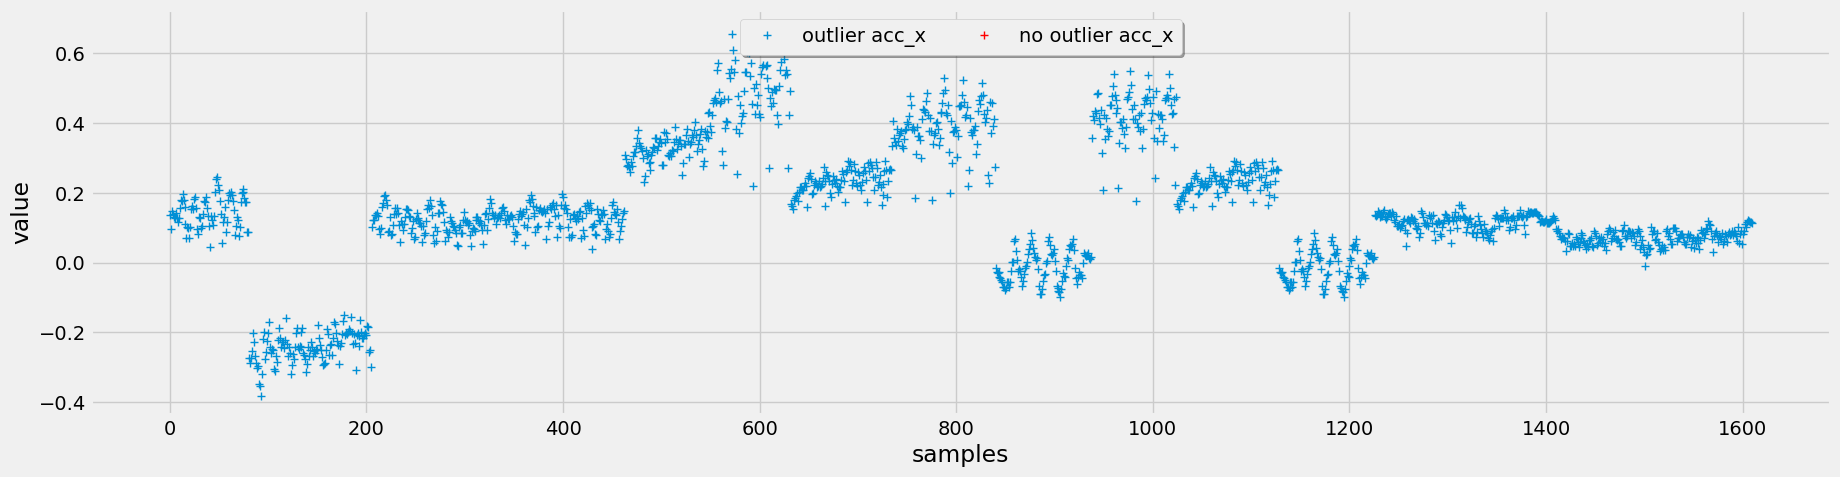

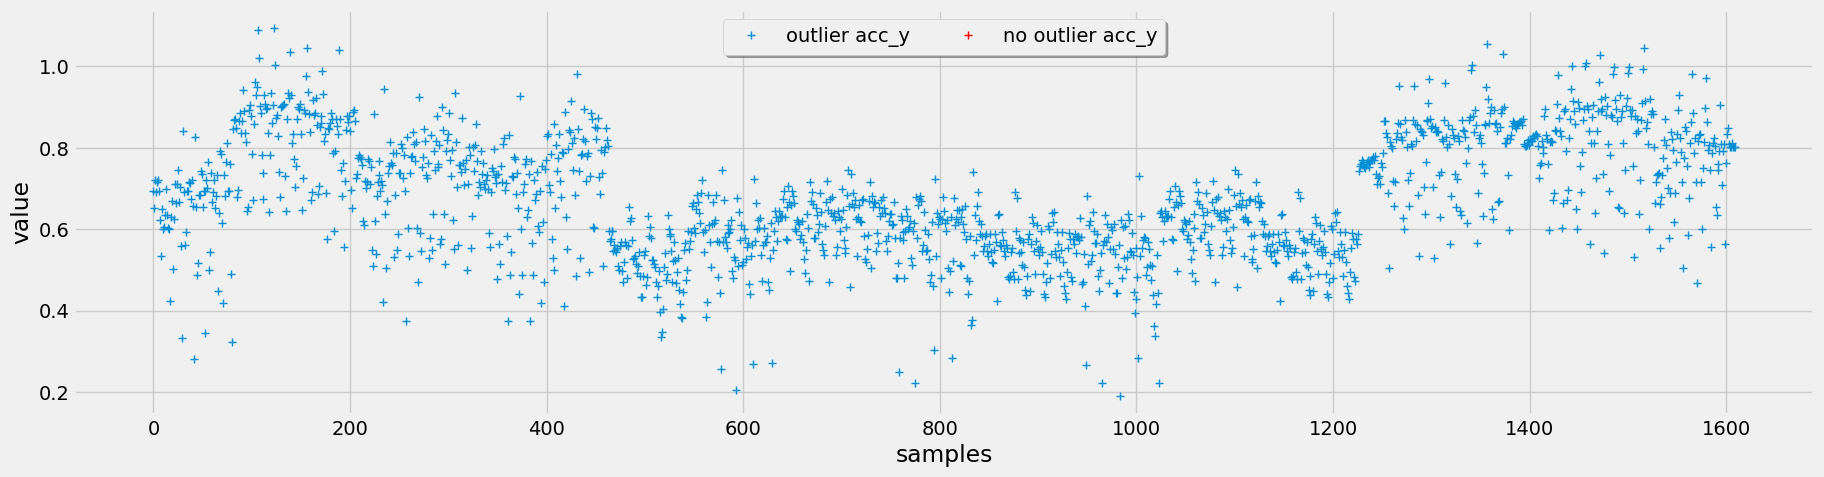

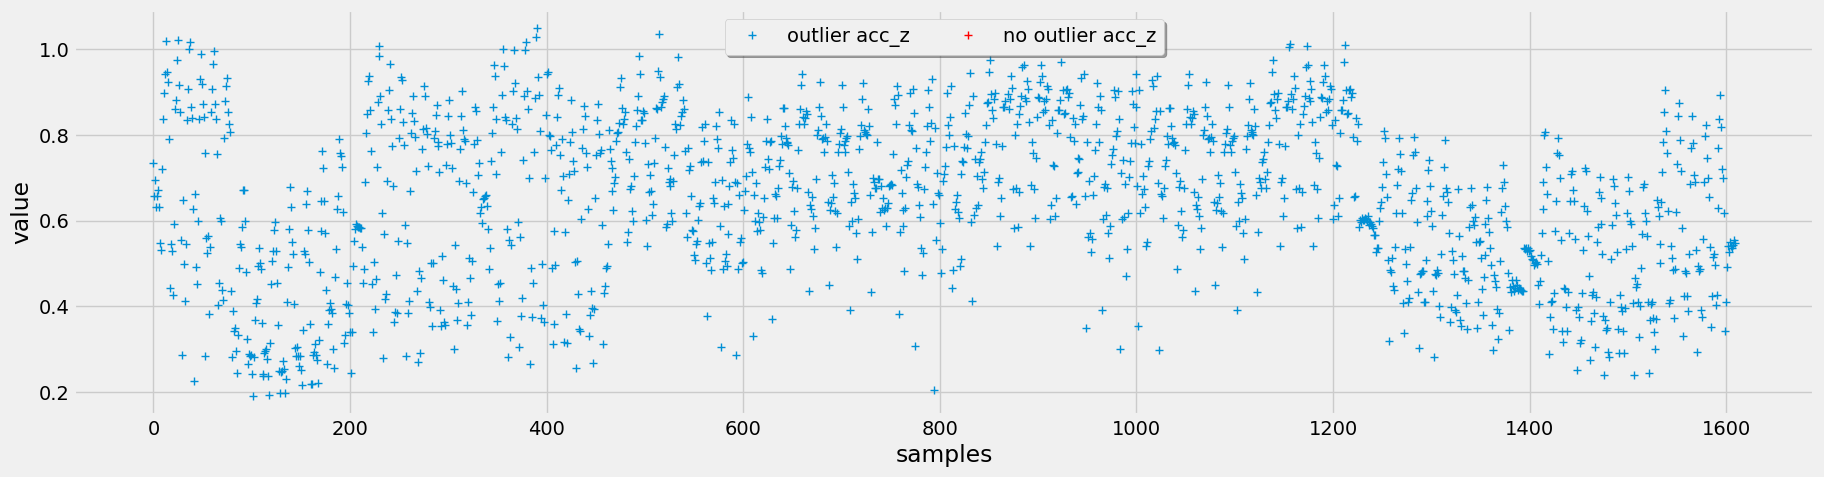

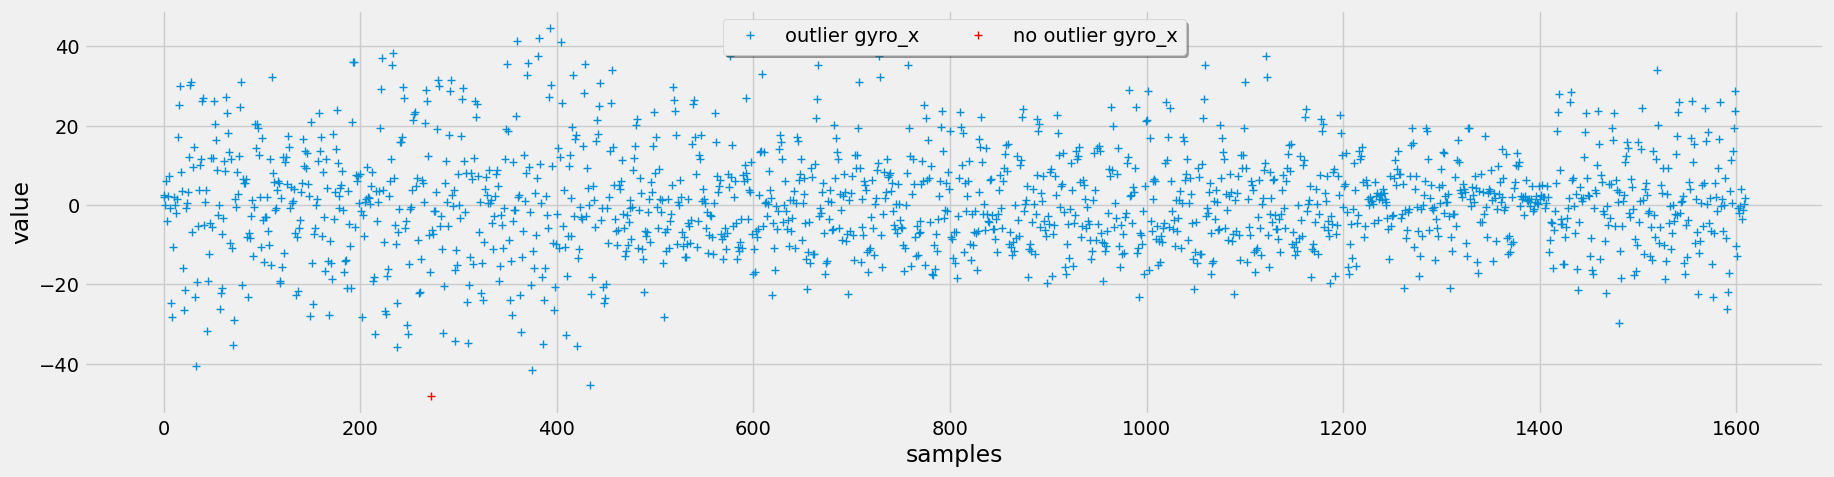

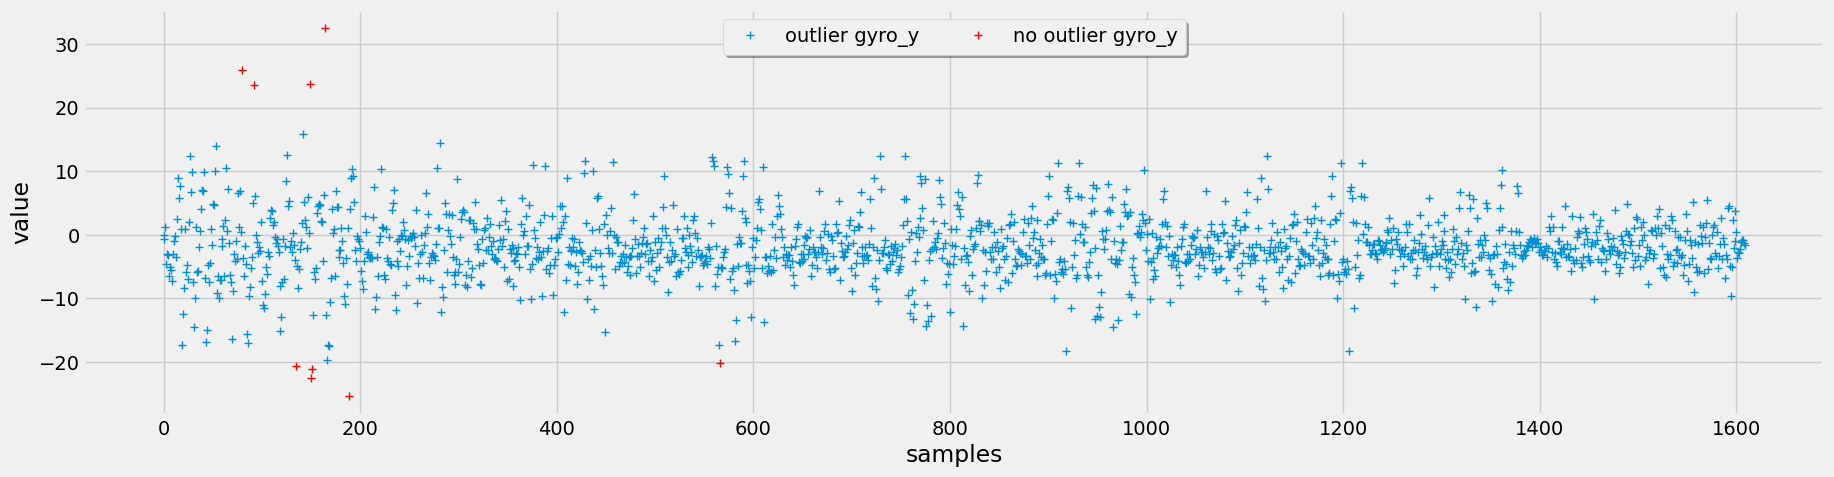

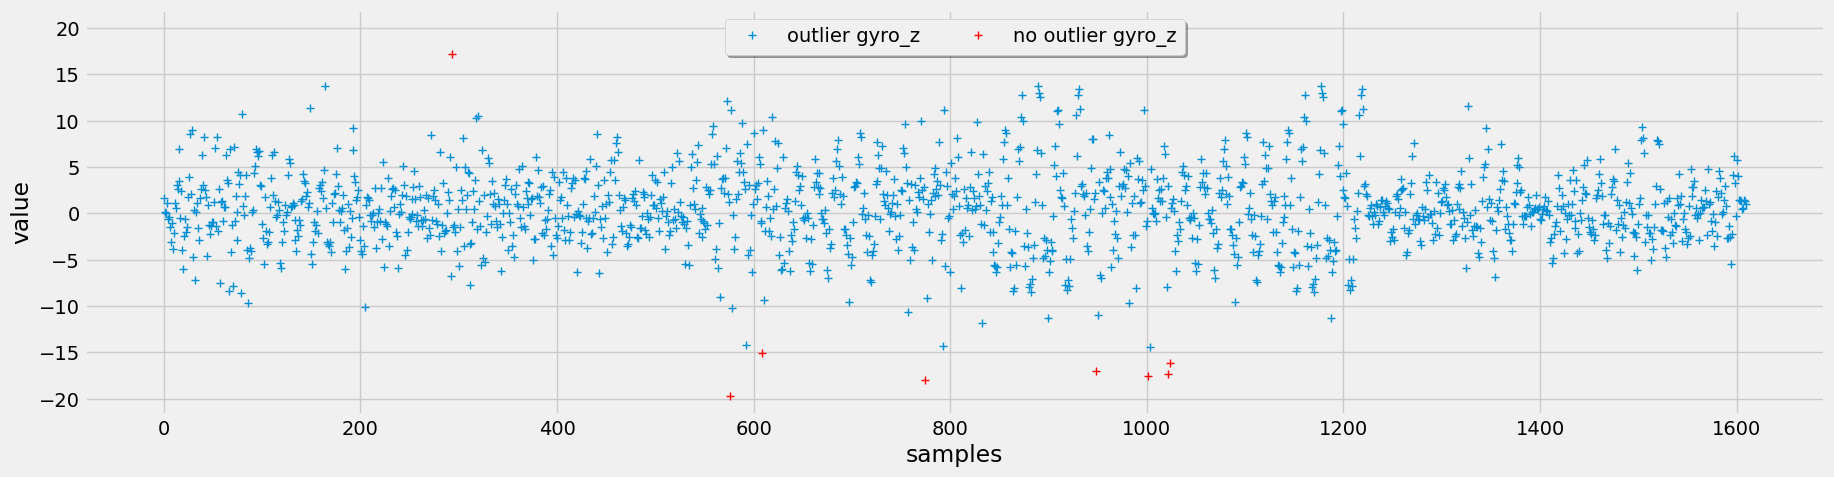

In [60]:
label = 'squat'

for col in outlier_col:
    dataset = mark_outliers_chauvenet(df[df['label'] == label], col)
    plot_binary_outliers(dataset=dataset, col=col,outlier_col= col+'_outlier', reset_index=True )

In [61]:
# export the cleaned data
outliers_removed_df.to_pickle('../data/interim/02_data_outliers_removed.pkl')